In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (20.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126441 files and direc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

In [71]:
# 데이터 로드 (파일명 변경 필요)
# news_3key = pd.read_csv('/content/news_sentiment_ssl_fixed_20250920_161607(키워드3개이상언급_감성분석).csv', encoding='utf-8-sig')
news_3key = pd.read_csv("/content/뉴스감성분석(개선판_키워드3개기사만)_20250922_021928.csv", encoding='utf-8-sig')
news_1key = pd.read_csv('/content/news_sentiment_ssl_fixed_20250920_174322(키워드1개이상언급_감성분석).csv', encoding='utf-8-sig')

In [72]:
news_3key['부정확률'] = pd.to_numeric(news_3key['부정확률'], errors ='coerce')
news_3key['긍정확률'] = pd.to_numeric(news_3key['긍정확률'], errors ='coerce')

In [73]:
news_1key['부정확률'] = pd.to_numeric(news_1key['부정확률'], errors ='coerce')
news_1key['긍정확률'] = pd.to_numeric(news_1key['긍정확률'], errors ='coerce')

In [74]:
news_1key['기사날짜'] = pd.to_datetime(news_1key['기사날짜'])
news_1key['기사년도'] = news_1key['기사날짜'].dt.year
news_1key['기사월'] = news_1key['기사날짜'].dt.month
news_1key['기사요일'] = news_1key['기사날짜'].dt.day_of_week

In [75]:
news_3key['기사날짜'] = pd.to_datetime(news_3key['기사날짜'])
news_3key['기사년도'] = news_3key['기사날짜'].dt.year
news_3key['기사월'] = news_3key['기사날짜'].dt.month
news_3key['기사요일'] = news_3key['기사날짜'].dt.day_of_week

In [76]:
news_3key.describe()

,기사날짜,긍정확률,부정확률,신뢰도,감성점수,처리시간,기사년도,기사월,기사요일
count,12789,12789.000000,12789.000000,12789.000000,12789.000000,12789.000000,12789.000000,12789.000000,12789.000000
mean,2023-07-31 19:23:07.473609984,0.646371,0.353629,0.687332,0.292741,0.054918,2023.018062,7.262178,2.062788
min,2015-01-19 00:00:00,0.114300,0.122500,0.500100,-0.771400,0.018451,2015.000000,1.000000,0.000000
25%,2023-02-14 00:00:00,0.565300,0.219200,0.608600,0.130600,0.038836,2023.000000,5.000000,1.000000
50%,2024-03-04 00:00:00,0.648500,0.351500,0.660600,0.297000,0.040394,2024.000000,7.000000,2.000000
75%,2024-08-21 00:00:00,0.780800,0.434700,0.783800,0.561600,0.042948,2024.000000,10.000000,3.000000
max,2024-12-31 00:00:00,0.877500,0.885700,0.885700,0.755000,2.059248,2024.000000,12.000000,6.000000
std,NaN,0.159612,0.159612,0.108657,0.319221,0.147456,1.549083,3.343909,1.500823


In [77]:
# company_establishment_info
news_3key['종목명']

,종목명
0,휴맥스
1,휴림로봇
2,에이직랜드
3,버넥트
4,아이앤씨
...,...
12784,데이터스트림즈
12785,씨이랩
12786,데이터스트림즈
12787,브이엠


In [78]:
import pandas as pd
import numpy as np

# 예시 데이터
# df = pd.read_csv('news_sentiment.csv')  # year, pos_prob, neg_prob, ...
# year 는 datetime에서 추출했다면 df['year'] = df['date'].dt.year

# 통계에 포함할 컬럼
cols = ['감성점수'] # '긍정확률', '부정확률', '신뢰도',

# groupby + agg 로 연도별 기술통계
summary = (
    news_3key.groupby('기사년도')[cols]
      .agg(['count', 'mean', 'std', 'min',
            lambda x: np.percentile(x,25),
            'median',
            lambda x: np.percentile(x,75),
            'max'])
)

# 컬럼명 보기 좋게
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)

print(summary.head())

   기사년도  감성점수_count  감성점수_mean  감성점수_std  감성점수_min  감성점수_<lambda_0>  \
0  2015          51   0.282624  0.378805   -0.7629         0.032600   
1  2016          82   0.324305  0.334043   -0.3674         0.032600   
2  2017          75   0.209211  0.294418   -0.3674         0.032600   
3  2018          73   0.247770  0.315955   -0.5803         0.128700   
4  2019         144   0.307382  0.337626   -0.5132         0.101825   

   감성점수_median  감성점수_<lambda_1>  감성점수_max  
0      0.31260         0.699350    0.7507  
1      0.29415         0.697425    0.7507  
2      0.12860         0.365600    0.7364  
3      0.27710         0.518200    0.7507  
4      0.29710         0.688450    0.7507  


##### 테이블1 (가설1용 뉴스감성 데이터요약)

In [84]:
pd.DataFrame(news_3key.groupby('기사년도')['감성점수'].describe()).to_csv("TABLE1_가설1_뉴스감성데이터요약.csv",encoding='utf-8-sig')

In [79]:
summary

,기사년도,감성점수_count,감성점수_mean,감성점수_std,감성점수_min,감성점수_<lambda_0>,감성점수_median,감성점수_<lambda_1>,감성점수_max
0,2015,51,0.282624,0.378805,-0.7629,0.032600,0.31260,0.699350,0.7507
1,2016,82,0.324305,0.334043,-0.3674,0.032600,0.29415,0.697425,0.7507
2,2017,75,0.209211,0.294418,-0.3674,0.032600,0.12860,0.365600,0.7364
3,2018,73,0.247770,0.315955,-0.5803,0.128700,0.27710,0.518200,0.7507
4,2019,144,0.307382,0.337626,-0.5132,0.101825,0.29710,0.688450,0.7507
5,2020,529,0.307576,0.309800,-0.7714,0.180900,0.29550,0.577500,0.7550
6,2021,873,0.308127,0.286322,-0.7552,0.182600,0.30440,0.530800,0.7530
7,2022,1195,0.283959,0.336215,-0.6994,0.133550,0.29560,0.577500,0.7550
8,2023,2635,0.291619,0.329348,-0.7579,0.137200,0.30030,0.575350,0.7550
9,2024,7132,0.292396,0.316197,-0.7503,0.127475,0.29665,0.552750,0.7550


In [28]:
pd.read_csv("/content/최종검정용뉴스감성(상위권).csv")['종목명'].unique()

array(['휴맥스', '우리넷', '베노티앤알', '에이디테크놀로지', 'BF랩스', '파수', '메가스터디교육', '한진칼',
       '그린생명과학', '케이사인', '일진전기', '포톤', '화인베스틸', '시큐브', '뉴온', '심텍',
       '강원에너지', '주성코퍼레이션', '사람인', '에이팩트', '현대퓨처넷', '하이비젼시스템', '노블엠앤비',
       '인바이오젠', '피제이메탈'], dtype=object)

In [30]:
pd.read_csv("/content/최종검정용뉴스감성(상위권).csv")['종목코드'].unique()

array([115160, 115440, 206400, 200710, 139050, 150900, 215200, 180640,
       114450, 192250, 103590, 208710, 133820, 131090, 123840, 222800,
       114190, 109070, 143240, 200470, 126560, 126700, 106520, 101140,
       128660])

In [29]:
pd.read_csv("/content/최종검정용뉴스감성(하위권).csv")['종목명'].unique()

array(['버넥트', '에이직랜드', '코어라인소프트', '아이지넷', '사이냅소프트', 'LS머트리얼즈', '미트박스',
       '크라우드웍스', '그린리소스', '산돌', '샌즈랩', '피아이이', '컨텍', '루미르', '워트', '온코크로스',
       '에스지헬스케어', '모니터랩', '모코엠시스', '아이씨에이치', 'HD현대마린솔루션', '한화플러스제5호스팩',
       '클로봇', '파두', '파로스아이바이오', '삼양엔씨켐', '오픈놀', 'SK스퀘어', '포스뱅크',
       '아이스크림미디어', '비아이매트릭스', '교보17호스팩', '아스테라시스', '엑스게이트', '아이빔테크놀로지',
       '샤페론', '삐아', '벡트', '큐리옥스바이오시스템즈', '뉴로메카', '컴퍼니케이', '동인기연',
       '한주라이트메탈', '사피엔반도체', 'M83', '핀텔', '세니젠', '다원넥스뷰', '지아이이노베이션',
       '뱅크웨어글로벌', '엠디바이스', 'HB인베스트먼트', '에이에스텍', 'DB금융스팩12호', '시큐레터',
       '코람코라이프인프라리츠', '아이언디바이스', '아이에스티이', '디앤디파마텍', '에코프로머티', '데이원컴퍼니',
       'IBKS제22호스팩', '블루엠텍', '코닉오토메이션', '유투바이오', '큐알티', '하나32호스팩', '에이럭스',
       '제이엔비', 'NH올원리츠', '신한제14호스팩', '펨트론', '나노팀', '화인써키트', '레뷰코퍼레이션',
       '에이텀', '이닉스', '모티브링크', '라이콤', '유진스팩10호', '윤성에프앤씨', '신한제15호스팩',
       '에스비비테크', '나우IB', '한국제12호스팩'], dtype=object)

In [31]:
pd.read_csv("/content/최종검정용뉴스감성(하위권).csv")['종목코드'].unique()

array([438700, 445090, 384470, 462980, 466410, 417200, 475460, 355390,
       402490, 419120, 411080, 452450, 451760, 474170, 396470, 382150,
       398120, 434480, 333050, 368600, 443060, 498390, 466100, 440110,
       388870, 482630, 440320, 402340, 105760, 461300, 413640, 489210,
       450950, 356680, 460470, 378800, 451250, 457600, 445680, 348340,
       307930, 111380, 198940, 452430, 476080, 291810, 188260, 323350,
       358570, 199480, 226590, 440290, 453860, 477760, 418250, 357120,
       464500, 212710, 347850, 450080, 373160, 448760, 439580, 391710,
       221800, 405100, 475240, 475580, 452160, 400760, 487360, 168360,
       417010, 127980, 443250, 355690, 452400, 463480, 388790, 468760,
       372170, 487830, 389500, 293580, 458610])

In [32]:
len(pd.read_csv("/content/최종검정용뉴스감성(상위권).csv")['종목코드'].unique()) +\
len(pd.read_csv("/content/최종검정용뉴스감성(하위권).csv")['종목코드'].unique())

110

## 가설2에 해당하는 회사들 (회계정보 상위or하위)에 대해서, 기업 설립년도 전수 조사 및 정보 매핑

In [34]:
company_establishment_info = pd.read_excel("company_establishment_info.xlsx")
company_establishment_info.head()

,회사명,종목코드,확인된 설립 일자 (YYYY-MM-DD),법인 유형,주요 출처 (공시 문서 유형 및 날짜)
0,노블엠앤비,106520,2004-12-16,표준 사업 회사,DART 사업보고서 (2024)
1,인바이오젠,101140,1993-02-15,표준 사업 회사,DART 사업보고서 (2024)
2,일진전기,103590,1967-08-01,표준 사업 회사,DART 사업보고서 (2024)
3,주성코퍼레이션,109070,2002-12-10,표준 사업 회사,DART 사업보고서 (2024)
4,화인베스틸,133820,2010-09-17,표준 사업 회사,DART 사업보고서 (2024)


In [46]:
company_establishment_info['종목코드'] = company_establishment_info['종목코드'].astype(str)
company_establishment_info['종목코드'].iloc[0]

'106520'

In [38]:
company_establishment_info['설립년도'] = pd.to_datetime(company_establishment_info.iloc[:,2]).dt.year
company_establishment_info.describe()

,종목코드,설립년도
count,110.000000,110.000000
mean,337069.090909,2011.936364
std,132942.357444,9.041471
min,101140.000000,1967.000000
25%,202132.500000,2008.000000
50%,389185.000000,2014.000000
75%,451175.000000,2017.000000
max,498390.000000,2024.000000


In [63]:
cols = ['감성점수']

# groupby + agg 로 연도별 기술통계
summary = (
    pd.merge(news_3key,company_establishment_info,on='종목코드').describe().groupby('기사년도')[cols]
      .agg(['count', 'mean', 'std', 'min',
            lambda x: np.percentile(x,25),
            'median',
            lambda x: np.percentile(x,75),
            'max'])
)

# 컬럼명 보기 좋게
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)

print(summary.head())

          기사년도  감성점수_count    감성점수_mean  감성점수_std     감성점수_min  \
0     1.515414           1     0.323951       NaN     0.323951   
1  1649.000000           1  1649.000000       NaN  1649.000000   
2  2015.000000           1    -0.750300       NaN    -0.750300   
3  2023.000000           1     0.144800       NaN     0.144800   
4  2023.086719           1     0.300373       NaN     0.300373   

   감성점수_<lambda_0>  감성점수_median  감성점수_<lambda_1>     감성점수_max  
0         0.323951     0.323951         0.323951     0.323951  
1      1649.000000  1649.000000      1649.000000  1649.000000  
2        -0.750300    -0.750300        -0.750300    -0.750300  
3         0.144800     0.144800         0.144800     0.144800  
4         0.300373     0.300373         0.300373     0.300373  


### 최종 가설2를 위한 뉴스 데이터 정보 요약

In [70]:
pd.merge(news_3key,company_establishment_info,on='종목코드').groupby('기사년도')['감성점수'].describe()

,count,mean,std,min,25%,50%,75%,max
기사년도,,,,,,,,
2015,12.0,0.136025,0.411818,-0.3674,-0.210200,0.17210,0.381375,0.7507
2016,8.0,0.068638,0.407816,-0.3674,-0.367400,0.14620,0.291800,0.7507
2017,6.0,0.175383,0.470316,-0.3674,-0.233775,0.21785,0.528400,0.7364
2018,7.0,-0.021800,0.421948,-0.5803,-0.367400,0.06310,0.268350,0.5627
2019,16.0,0.156687,0.382538,-0.3674,-0.112250,0.21925,0.326175,0.7233
2020,49.0,0.298476,0.324770,-0.3674,0.178600,0.30130,0.530800,0.7114
2021,100.0,0.337546,0.265251,-0.3674,0.228250,0.30350,0.530800,0.7507
2022,186.0,0.355309,0.308351,-0.6994,0.220300,0.31110,0.680825,0.7507
2023,302.0,0.301387,0.337798,-0.7503,0.157325,0.30190,0.593875,0.7507


In [85]:
pd.merge(news_3key,company_establishment_info,on='종목코드').groupby('기사년도')['감성점수'].describe().to_csv("TABLE1_가설2_뉴스감성데이터요약.csv",encoding='utf-8-sig')

## EDA

### 등장 기사 년도

## DART , KRX

>> Q2 : 회계정보가 적을수록 기사 sentiment score가 그 기업의 가치를 설명하는데 영향을 많이 미친다

In [ ]:
dart = pd.read_excel("/content/dart_financial_merged(약700개_10년치)재무재표정보).xlsx")
krx = pd.read_csv("/content/market_table_quarterly(KRX시가총액정보_상장주식수_dart기준기업).csv")

In [ ]:
dart_list = pd.read_csv("/content/DART기업목록.csv",encoding='euc-kr')
dart_list.head(3)

,firm_id,종목코드
0,0,[6840]
1,1,[139050]
2,2,[126600]


In [ ]:
dart_list['종목코드'] = dart_list['종목코드'].apply(lambda x : ''.join(str(x))[1:-1])
dart_list

,firm_id,종목코드
0,0,6840
1,1,139050
2,2,126600
3,3,79160
4,4,35760
...,...,...
675,675,46400
676,676,243070
677,677,189980
678,678,3280


In [ ]:
dart

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드
0,5.611743e+12,4.390186e+12,1.221557e+12,9.509491e+11,-5.046980e+09,2025,11013,1분기보고서,2025-03-31,AK홀딩스,6840
1,5.617959e+12,4.429888e+12,1.188071e+12,9.319186e+11,-2.186179e+10,2025,11012,반기보고서,2025-06-30,AK홀딩스,6840
2,5.539372e+12,4.218362e+12,1.321009e+12,1.193398e+12,4.246371e+10,2024,11013,1분기보고서,2024-03-31,AK홀딩스,6840
3,5.573046e+12,4.271687e+12,1.301359e+12,1.132392e+12,-1.419845e+10,2024,11012,반기보고서,2024-06-30,AK홀딩스,6840
4,5.255263e+12,3.930349e+12,1.324914e+12,1.124705e+12,2.952720e+10,2024,11014,3분기보고서,2024-09-30,AK홀딩스,6840
...,...,...,...,...,...,...,...,...,...,...,...
18696,1.371201e+11,9.013820e+10,4.698195e+10,3.236204e+10,2.766586e+08,2016,11013,1분기보고서,2016-03-31,희림,37440
18697,1.390055e+11,9.143709e+10,4.756846e+10,3.506853e+10,5.760445e+08,2016,11012,반기보고서,2016-06-30,희림,37440
18698,1.377076e+11,8.983612e+10,4.787150e+10,3.603435e+10,2.679683e+08,2016,11014,3분기보고서,2016-09-30,희림,37440
18699,1.434174e+11,9.455628e+10,4.886110e+10,1.397726e+11,2.147517e+09,2016,11011,사업보고서,2016-12-31,희림,37440


In [ ]:
krx

,market_cap_krw,shares_outstanding,volume,value_traded,close_price,as_of_date,period_yyyyq,ticker,firm_id
0,91057472177,119341379,2451206,1829107088,763.0,20140331,2014-Q1,40,37
1,1504732680000,101328800,249887,3702102750,14850.0,20140331,2014-Q1,60,187
2,2577794872000,22812344,54901,6198534500,113000.0,20140331,2014-Q1,120,5
3,237162000000,67280000,85589,304081475,3525.0,20140331,2014-Q1,400,171
4,33825000000,5500000,1590,9681200,6150.0,20140331,2014-Q1,520,245
...,...,...,...,...,...,...,...,...,...
21887,10646550000,5310000,5292,10604405,NaN,20250630,2025-Q2,493790,430
21888,9994400000,4960000,9246,18578640,NaN,20250630,2025-Q2,498390,652
21889,22250002752,53743968,4494,1855934,NaN,20250630,2025-Q2,900070,96
21890,131081784130,13017059,179341,1828617665,NaN,20250630,2025-Q2,950190,83


In [ ]:
merged_krx = pd.merge(krx,dart_list)
merged_krx

,market_cap_krw,shares_outstanding,volume,value_traded,close_price,as_of_date,period_yyyyq,ticker,firm_id,종목코드
0,91057472177,119341379,2451206,1829107088,763.0,20140331,2014-Q1,40,37,40
1,1504732680000,101328800,249887,3702102750,14850.0,20140331,2014-Q1,60,187,60
2,2577794872000,22812344,54901,6198534500,113000.0,20140331,2014-Q1,120,5,120
3,237162000000,67280000,85589,304081475,3525.0,20140331,2014-Q1,400,171,400
4,33825000000,5500000,1590,9681200,6150.0,20140331,2014-Q1,520,245,520
...,...,...,...,...,...,...,...,...,...,...
21887,10646550000,5310000,5292,10604405,NaN,20250630,2025-Q2,493790,430,493790
21888,9994400000,4960000,9246,18578640,NaN,20250630,2025-Q2,498390,652,498390
21889,22250002752,53743968,4494,1855934,NaN,20250630,2025-Q2,900070,96,900070
21890,131081784130,13017059,179341,1828617665,NaN,20250630,2025-Q2,950190,83,950190


In [ ]:
to_merge_krx = merged_krx[['market_cap_krw','종목코드','as_of_date']]
to_merge_krx

,market_cap_krw,종목코드,as_of_date
0,91057472177,40,20140331
1,1504732680000,60,20140331
2,2577794872000,120,20140331
3,237162000000,400,20140331
4,33825000000,520,20140331
...,...,...,...
21887,10646550000,493790,20250630
21888,9994400000,498390,20250630
21889,22250002752,900070,20250630
21890,131081784130,950190,20250630


In [ ]:
def split_date(x):
  year = str(x)[:4]
  month = str(x)[4:6]
  day = str(x)[6:]
  return year+'-'+month+'-'+day

In [ ]:
to_merge_krx['report_date'] =  to_merge_krx['as_of_date'].apply(lambda x : split_date(x))
to_merge_krx

/tmp/ipython-input-2211801100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_merge_krx['report_date'] =  to_merge_krx['as_of_date'].apply(lambda x : split_date(x))


,market_cap_krw,종목코드,as_of_date,report_date
0,91057472177,40,20140331,2014-03-31
1,1504732680000,60,20140331,2014-03-31
2,2577794872000,120,20140331,2014-03-31
3,237162000000,400,20140331,2014-03-31
4,33825000000,520,20140331,2014-03-31
...,...,...,...,...
21887,10646550000,493790,20250630,2025-06-30
21888,9994400000,498390,20250630,2025-06-30
21889,22250002752,900070,20250630,2025-06-30
21890,131081784130,950190,20250630,2025-06-30


In [ ]:
del to_merge_krx['as_of_date']

KeyError: 'as_of_date'

In [ ]:
dart['종목코드'] = dart['종목코드'].apply(lambda x : str(x))

In [ ]:
print(
    type(to_merge_krx['종목코드'][0]),
    type(dart['종목코드'][0])
)

<class 'str'> <class 'str'>


In [ ]:
to_merge_krx

,market_cap_krw,종목코드,report_date
0,91057472177,40,2014-03-31
1,1504732680000,60,2014-03-31
2,2577794872000,120,2014-03-31
3,237162000000,400,2014-03-31
4,33825000000,520,2014-03-31
...,...,...,...
21887,10646550000,493790,2025-06-30
21888,9994400000,498390,2025-06-30
21889,22250002752,900070,2025-06-30
21890,131081784130,950190,2025-06-30


In [ ]:
pd.merge(dart,to_merge_krx)

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw
0,5.611743e+12,4.390186e+12,1.221557e+12,9.509491e+11,-5.046980e+09,2025,11013,1분기보고서,2025-03-31,AK홀딩스,6840,130488475850
1,5.617959e+12,4.429888e+12,1.188071e+12,9.319186e+11,-2.186179e+10,2025,11012,반기보고서,2025-06-30,AK홀딩스,6840,154201610040
2,5.539372e+12,4.218362e+12,1.321009e+12,1.193398e+12,4.246371e+10,2024,11013,1분기보고서,2024-03-31,AK홀딩스,6840,0
3,5.573046e+12,4.271687e+12,1.301359e+12,1.132392e+12,-1.419845e+10,2024,11012,반기보고서,2024-06-30,AK홀딩스,6840,0
4,5.255263e+12,3.930349e+12,1.324914e+12,1.124705e+12,2.952720e+10,2024,11014,3분기보고서,2024-09-30,AK홀딩스,6840,170761061290
...,...,...,...,...,...,...,...,...,...,...,...,...
18326,1.371201e+11,9.013820e+10,4.698195e+10,3.236204e+10,2.766586e+08,2016,11013,1분기보고서,2016-03-31,희림,37440,63973772625
18327,1.390055e+11,9.143709e+10,4.756846e+10,3.506853e+10,5.760445e+08,2016,11012,반기보고서,2016-06-30,희림,37440,77826635250
18328,1.377076e+11,8.983612e+10,4.787150e+10,3.603435e+10,2.679683e+08,2016,11014,3분기보고서,2016-09-30,희림,37440,80193456000
18329,1.434174e+11,9.455628e+10,4.886110e+10,1.397726e+11,2.147517e+09,2016,11011,사업보고서,2016-12-31,희림,37440,0


In [ ]:
to_merge_krx

,market_cap_krw,종목코드,report_date
0,91057472177,40,2014-03-31
1,1504732680000,60,2014-03-31
2,2577794872000,120,2014-03-31
3,237162000000,400,2014-03-31
4,33825000000,520,2014-03-31
...,...,...,...
21887,10646550000,493790,2025-06-30
21888,9994400000,498390,2025-06-30
21889,22250002752,900070,2025-06-30
21890,131081784130,950190,2025-06-30


In [ ]:
dart, to_merge_krx

(               자산총계          부채총계          자본총계           매출액         당기순이익  \
 0      5.611743e+12  4.390186e+12  1.221557e+12  9.509491e+11 -5.046980e+09   
 1      5.617959e+12  4.429888e+12  1.188071e+12  9.319186e+11 -2.186179e+10   
 2      5.539372e+12  4.218362e+12  1.321009e+12  1.193398e+12  4.246371e+10   
 3      5.573046e+12  4.271687e+12  1.301359e+12  1.132392e+12 -1.419845e+10   
 4      5.255263e+12  3.930349e+12  1.324914e+12  1.124705e+12  2.952720e+10   
 ...             ...           ...           ...           ...           ...   
 18696  1.371201e+11  9.013820e+10  4.698195e+10  3.236204e+10  2.766586e+08   
 18697  1.390055e+11  9.143709e+10  4.756846e+10  3.506853e+10  5.760445e+08   
 18698  1.377076e+11  8.983612e+10  4.787150e+10  3.603435e+10  2.679683e+08   
 18699  1.434174e+11  9.455628e+10  4.886110e+10  1.397726e+11  2.147517e+09   
 18700  1.424960e+11  9.467022e+10  4.782581e+10  1.357709e+11  3.648859e+09   
 
        bsns_year  reprt_code report_n

### Tobin’s Q = (시가총액 + 총부채) / 총자산

In [ ]:
# dart 기준으로 merge (left join)
merged_dart_df = pd.merge(
    dart,
    to_merge_krx[['종목코드','report_date','market_cap_krw']],
    how='left',
    on=['종목코드','report_date']
)

# 결과 확인
print(merged_dart_df.head())

           자산총계          부채총계          자본총계           매출액         당기순이익  \
0  5.611743e+12  4.390186e+12  1.221557e+12  9.509491e+11 -5.046980e+09   
1  5.617959e+12  4.429888e+12  1.188071e+12  9.319186e+11 -2.186179e+10   
2  5.539372e+12  4.218362e+12  1.321009e+12  1.193398e+12  4.246371e+10   
3  5.573046e+12  4.271687e+12  1.301359e+12  1.132392e+12 -1.419845e+10   
4  5.255263e+12  3.930349e+12  1.324914e+12  1.124705e+12  2.952720e+10   

   bsns_year  reprt_code report_name report_date    기업명  종목코드  market_cap_krw  
0       2025       11013      1분기보고서  2025-03-31  AK홀딩스  6840    1.304885e+11  
1       2025       11012       반기보고서  2025-06-30  AK홀딩스  6840    1.542016e+11  
2       2024       11013      1분기보고서  2024-03-31  AK홀딩스  6840    0.000000e+00  
3       2024       11012       반기보고서  2024-06-30  AK홀딩스  6840    0.000000e+00  
4       2024       11014      3분기보고서  2024-09-30  AK홀딩스  6840    1.707611e+11  


In [ ]:
merged_dart_df

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw
0,5.611743e+12,4.390186e+12,1.221557e+12,9.509491e+11,-5.046980e+09,2025,11013,1분기보고서,2025-03-31,AK홀딩스,6840,1.304885e+11
1,5.617959e+12,4.429888e+12,1.188071e+12,9.319186e+11,-2.186179e+10,2025,11012,반기보고서,2025-06-30,AK홀딩스,6840,1.542016e+11
2,5.539372e+12,4.218362e+12,1.321009e+12,1.193398e+12,4.246371e+10,2024,11013,1분기보고서,2024-03-31,AK홀딩스,6840,0.000000e+00
3,5.573046e+12,4.271687e+12,1.301359e+12,1.132392e+12,-1.419845e+10,2024,11012,반기보고서,2024-06-30,AK홀딩스,6840,0.000000e+00
4,5.255263e+12,3.930349e+12,1.324914e+12,1.124705e+12,2.952720e+10,2024,11014,3분기보고서,2024-09-30,AK홀딩스,6840,1.707611e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
18696,1.371201e+11,9.013820e+10,4.698195e+10,3.236204e+10,2.766586e+08,2016,11013,1분기보고서,2016-03-31,희림,37440,6.397377e+10
18697,1.390055e+11,9.143709e+10,4.756846e+10,3.506853e+10,5.760445e+08,2016,11012,반기보고서,2016-06-30,희림,37440,7.782664e+10
18698,1.377076e+11,8.983612e+10,4.787150e+10,3.603435e+10,2.679683e+08,2016,11014,3분기보고서,2016-09-30,희림,37440,8.019346e+10
18699,1.434174e+11,9.455628e+10,4.886110e+10,1.397726e+11,2.147517e+09,2016,11011,사업보고서,2016-12-31,희림,37440,0.000000e+00


In [ ]:
merged_dart_df['tobin_Q'] = (merged_dart_df['market_cap_krw']+merged_dart_df['부채총계'])/merged_dart_df['자산총계']

# 가설1 검정

In [ ]:
merged_dart_df

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q
0,5.611743e+12,4.390186e+12,1.221557e+12,9.509491e+11,-5.046980e+09,2025,11013,1분기보고서,2025-03-31,AK홀딩스,6840,1.304885e+11,0.805574
1,5.617959e+12,4.429888e+12,1.188071e+12,9.319186e+11,-2.186179e+10,2025,11012,반기보고서,2025-06-30,AK홀딩스,6840,1.542016e+11,0.815971
2,5.539372e+12,4.218362e+12,1.321009e+12,1.193398e+12,4.246371e+10,2024,11013,1분기보고서,2024-03-31,AK홀딩스,6840,0.000000e+00,0.761524
3,5.573046e+12,4.271687e+12,1.301359e+12,1.132392e+12,-1.419845e+10,2024,11012,반기보고서,2024-06-30,AK홀딩스,6840,0.000000e+00,0.766491
4,5.255263e+12,3.930349e+12,1.324914e+12,1.124705e+12,2.952720e+10,2024,11014,3분기보고서,2024-09-30,AK홀딩스,6840,1.707611e+11,0.780382
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18696,1.371201e+11,9.013820e+10,4.698195e+10,3.236204e+10,2.766586e+08,2016,11013,1분기보고서,2016-03-31,희림,37440,6.397377e+10,1.123919
18697,1.390055e+11,9.143709e+10,4.756846e+10,3.506853e+10,5.760445e+08,2016,11012,반기보고서,2016-06-30,희림,37440,7.782664e+10,1.217676
18698,1.377076e+11,8.983612e+10,4.787150e+10,3.603435e+10,2.679683e+08,2016,11014,3분기보고서,2016-09-30,희림,37440,8.019346e+10,1.234714
18699,1.434174e+11,9.455628e+10,4.886110e+10,1.397726e+11,2.147517e+09,2016,11011,사업보고서,2016-12-31,희림,37440,0.000000e+00,0.659308


In [ ]:
news_3key['종목코드'] = news_3key['종목코드'].astype(str)

In [ ]:
# 결과를 담을 리스트
results = []

for year in merged_dart_df['bsns_year'].unique():
    temp_year = merged_dart_df[merged_dart_df['bsns_year'] == year]
    for code in merged_dart_df['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_all = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_all)

        년도    종목코드      기업명  Tobin_Q(평균)  긍정점수평균  긍정점수중위수  긍정점수표준편차  부정점수평균  \
0     2015    1000     신라섬유     0.603134     NaN      NaN       NaN     NaN   
1     2015  100130    동국S&C     0.313755     NaN      NaN       NaN     NaN   
2     2015  101140    인바이오젠     0.464266     NaN      NaN       NaN     NaN   
3     2015   10120  엘에스일렉트릭     0.549358     NaN      NaN       NaN     NaN   
4     2015  102280      쌍방울     0.186173     NaN      NaN       NaN     NaN   
...    ...     ...      ...          ...     ...      ...       ...     ...   
5400  2025   96250     와이즈넛     2.504260     NaN      NaN       NaN     NaN   
5401  2025    9770     삼정펄프     0.343108     NaN      NaN       NaN     NaN   
5402  2025   98070       한텍     2.185435     NaN      NaN       NaN     NaN   
5403  2025   98460       고영     2.867691     NaN      NaN       NaN     NaN   
5404  2025   99750    이지케어텍     2.606026     NaN      NaN       NaN     NaN   

      부정점수중위수  부정점수표준편차  
0         NaN       NaN  

In [ ]:
# 결과를 담을 리스트
results = []

for year in merged_dart_df['bsns_year'].unique():
    temp_year = merged_dart_df[merged_dart_df['bsns_year'] == year]
    for code in merged_dart_df['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_all_key1 = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_all_key1)

/tmp/ipython-input-1477173364.py:15: RuntimeWarning: Mean of empty slice
  '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipython-input-1477173364.py:18: RuntimeWarning: Mean of empty slice
  '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
/tmp/ipython-input-1477173364.py:14: RuntimeWarning: Mean of empty slice
  'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),


        년도    종목코드      기업명  Tobin_Q(평균)  긍정점수평균  긍정점수중위수  긍정점수표준편차  부정점수평균  \
0     2015    1000     신라섬유     0.603134     NaN      NaN       NaN     NaN   
1     2015  100130    동국S&C     0.313755     NaN      NaN       NaN     NaN   
2     2015  101140    인바이오젠     0.464266     NaN      NaN       NaN     NaN   
3     2015   10120  엘에스일렉트릭     0.549358     NaN      NaN       NaN     NaN   
4     2015  102280      쌍방울     0.186173     NaN      NaN       NaN     NaN   
...    ...     ...      ...          ...     ...      ...       ...     ...   
5400  2025   96250     와이즈넛     2.504260     NaN      NaN       NaN     NaN   
5401  2025    9770     삼정펄프     0.343108     NaN      NaN       NaN     NaN   
5402  2025   98070       한텍     2.185435     NaN      NaN       NaN     NaN   
5403  2025   98460       고영     2.867691     NaN      NaN       NaN     NaN   
5404  2025   99750    이지케어텍     2.606026     NaN      NaN       NaN     NaN   

      부정점수중위수  부정점수표준편차  
0         NaN       NaN  

# 가설1 검정

In [ ]:
tobin_df_all.dropna()

,년도,종목코드,기업명,Tobin_Q(평균),긍정점수평균,긍정점수중위수,긍정점수표준편차,부정점수평균,부정점수중위수,부정점수표준편차
84,2015,208710,포톤,0.318940,0.605180,0.65000,0.154697,0.394820,0.35000,0.154697
418,2016,208710,포톤,1.454225,0.596700,0.59670,0.000000,0.403300,0.40330,0.000000
700,2017,105550,엣지파운드리,1.157106,0.733825,0.75405,0.105959,0.266175,0.24595,0.105959
852,2017,258610,케일럼,0.443309,0.558800,0.55880,0.000000,0.441200,0.44120,0.000000
1112,2018,105550,엣지파운드리,0.631366,0.581700,0.58170,0.000000,0.418300,0.41830,0.000000
...,...,...,...,...,...,...,...,...,...,...
4730,2024,93320,케이아이엔엑스,0.596624,0.729340,0.69780,0.101305,0.270660,0.30220,0.101305
4732,2024,93640,케이알엠,0.707845,0.767214,0.85630,0.132768,0.232786,0.14370,0.132768
4738,2024,96240,크레버스,1.034426,0.744200,0.74420,0.000000,0.255800,0.25580,0.000000
4741,2024,98460,고영,0.657515,0.764875,0.76755,0.085284,0.235125,0.23245,0.085284


In [ ]:
tobin_df_all.to_csv("기사3개짜리_전체뉴스분석_토빈효과포함(개선판).csv")

In [ ]:
tobin_df_all.dropna().corr(numeric_only=True)

,년도,Tobin_Q(평균),긍정점수평균,긍정점수중위수,긍정점수표준편차,부정점수평균,부정점수중위수,부정점수표준편차
년도,1.000000,-0.193187,0.021961,0.024776,0.137356,-0.021961,-0.024776,0.137356
Tobin_Q(평균),-0.193187,1.000000,0.000790,-0.006179,-0.095466,-0.000790,0.006179,-0.095466
긍정점수평균,0.021961,0.000790,1.000000,0.968926,-0.190851,-1.000000,-0.968926,-0.190851
긍정점수중위수,0.024776,-0.006179,0.968926,1.000000,-0.124993,-0.968926,-1.000000,-0.124993
긍정점수표준편차,0.137356,-0.095466,-0.190851,-0.124993,1.000000,0.190851,0.124993,1.000000
부정점수평균,-0.021961,-0.000790,-1.000000,-0.968926,0.190851,1.000000,0.968926,0.190851
부정점수중위수,-0.024776,0.006179,-0.968926,-1.000000,0.124993,0.968926,1.000000,0.124993
부정점수표준편차,0.137356,-0.095466,-0.190851,-0.124993,1.000000,0.190851,0.124993,1.000000


In [ ]:
tobin_df_all_key1.to_csv("기사1개짜리_전체뉴스분석_토빈효과포함.csv")

In [ ]:
tobin_df_all_key1.dropna().corr(numeric_only=True)

,년도,Tobin_Q(평균),긍정점수평균,긍정점수중위수,긍정점수표준편차,부정점수평균,부정점수중위수,부정점수표준편차
년도,1.000000,0.029509,0.127050,0.142253,0.264584,-0.127050,-0.142253,0.264584
Tobin_Q(평균),0.029509,1.000000,-0.052031,-0.040680,0.006695,0.052031,0.040680,0.006695
긍정점수평균,0.127050,-0.052031,1.000000,0.960927,0.050114,-1.000000,-0.960927,0.050114
긍정점수중위수,0.142253,-0.040680,0.960927,1.000000,0.046068,-0.960927,-1.000000,0.046068
긍정점수표준편차,0.264584,0.006695,0.050114,0.046068,1.000000,-0.050114,-0.046068,1.000000
부정점수평균,-0.127050,0.052031,-1.000000,-0.960927,-0.050114,1.000000,0.960927,-0.050114
부정점수중위수,-0.142253,0.040680,-0.960927,-1.000000,-0.046068,0.960927,1.000000,-0.046068
부정점수표준편차,0.264584,0.006695,0.050114,0.046068,1.000000,-0.050114,-0.046068,1.000000


# 가설2 검정

### 회계정보가 적은 곳 vs 많은 곳?

In [ ]:
# "분기별 보고서"라는 10년치 자료에서 볼떄에, 가장 많은 정보는 39개의 report_date가 있는 기업, 가장 적은 곳은 고작 1개이다.
merged_dart_df.groupby(['종목코드'])['report_date'].agg(len).describe()

,report_date
count,680.000000
mean,27.501471
std,14.092582
min,1.000000
25%,12.000000
50%,38.000000
75%,39.000000
max,39.000000


In [ ]:
# 가장 적은 회계 정보 기업 (단순 보고서 수로 볼때)
merged_dart_df.loc[merged_dart_df.groupby(['종목코드'])['report_date'].agg(len).argmin()]

,247
자산총계,143409086635.0
부채총계,67719807379.0
자본총계,75689279256.0
매출액,152701471935.0
당기순이익,7419860689.0
bsns_year,2022
reprt_code,11011
report_name,사업보고서
report_date,2022-12-31
기업명,CJ씨푸드


In [ ]:
# 가장 많은 회계 정보 기업 (단순 보고서 수로 볼때)
merged_dart_df.loc[merged_dart_df.groupby(['종목코드'])['report_date'].agg(len).argmax()]

,0
자산총계,5611743327988.0
부채총계,4390185924788.0
자본총계,1221557403200.0
매출액,950949103097.0
당기순이익,-5046980067.0
bsns_year,2025
reprt_code,11013
report_name,1분기보고서
report_date,2025-03-31
기업명,AK홀딩스


## 회계정보 하위 25% (분기보고서 갯수가 하위권)

In [ ]:
print(merged_dart_df.groupby(['종목코드'])['report_date'].agg(len).quantile(0.25), # 하위권기준 -> 10년동안 8개 이하
      merged_dart_df.groupby(['종목코드'])['report_date'].agg(len).quantile(0.75)) # 상위권기준 -> 10년동안 39개 이상

12.0 39.0


In [ ]:
num_of_reports_lower_25_index =\
merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)[merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)<=12].index

In [ ]:
num_of_reports_lower_25 = merged_dart_df[merged_dart_df['종목코드'].isin(num_of_reports_lower_25_index)]
num_of_reports_lower_25

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q
291,7.666025e+11,4.776607e+11,2.889419e+11,2.481156e+11,6.307202e+09,2025,11013,1분기보고서,2025-03-31,DS단석,17860,4.026785e+11,1.148364
292,7.524511e+11,4.695435e+11,2.829076e+11,2.217253e+11,-5.398949e+09,2025,11012,반기보고서,2025-06-30,DS단석,17860,4.431221e+11,1.212924
293,7.245176e+11,4.406755e+11,2.838421e+11,2.185394e+11,2.172129e+09,2024,11013,1분기보고서,2024-03-31,DS단석,17860,0.000000e+00,0.608233
294,7.302603e+11,4.441110e+11,2.861493e+11,2.663082e+11,1.991084e+09,2024,11012,반기보고서,2024-06-30,DS단석,17860,0.000000e+00,0.608154
295,7.244559e+11,4.410071e+11,2.834488e+11,2.591143e+11,-2.842442e+09,2024,11014,3분기보고서,2024-09-30,DS단석,17860,4.507420e+11,1.230923
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18211,8.409840e+10,4.883947e+10,3.525892e+10,1.674333e+10,5.278984e+08,2023,11013,1분기보고서,2023-03-31,화인써키트,127980,2.048195e+11,3.016217
18212,1.011284e+11,6.140664e+10,3.972175e+10,1.766304e+10,9.979045e+08,2023,11012,반기보고서,2023-06-30,화인써키트,127980,1.449195e+11,2.040239
18213,1.005210e+11,5.861576e+10,4.190526e+10,1.738562e+10,9.547073e+08,2023,11014,3분기보고서,2023-09-30,화인써키트,127980,0.000000e+00,0.583119
18214,1.057658e+11,5.754272e+10,4.822312e+10,6.922234e+10,5.207565e+09,2023,11011,사업보고서,2023-12-31,화인써키트,127980,0.000000e+00,0.544058


## 회계정보 상위 25% (분기보고서 갯수가 상위권)

In [ ]:
merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)[merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)>=39].index

Index(['1000', '100130', '101140', '10120', '102280', '103590', '104460',
       '10470', '10580', '106080',
       ...
       '92870', '93230', '93370', '93640', '9410', '9440', '95910', '96240',
       '9770', '98460'],
      dtype='object', name='종목코드', length=292)

In [ ]:
num_of_reports_higher_25_index =\
merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)[merged_dart_df.groupby(['종목코드'])['report_date'].agg(len)>=39].index

In [ ]:
num_of_reports_higher_25 = merged_dart_df[merged_dart_df['종목코드'].isin(num_of_reports_higher_25_index)]
num_of_reports_higher_25

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q
0,5.611743e+12,4.390186e+12,1.221557e+12,9.509491e+11,-5.046980e+09,2025,11013,1분기보고서,2025-03-31,AK홀딩스,6840,1.304885e+11,0.805574
1,5.617959e+12,4.429888e+12,1.188071e+12,9.319186e+11,-2.186179e+10,2025,11012,반기보고서,2025-06-30,AK홀딩스,6840,1.542016e+11,0.815971
2,5.539372e+12,4.218362e+12,1.321009e+12,1.193398e+12,4.246371e+10,2024,11013,1분기보고서,2024-03-31,AK홀딩스,6840,0.000000e+00,0.761524
3,5.573046e+12,4.271687e+12,1.301359e+12,1.132392e+12,-1.419845e+10,2024,11012,반기보고서,2024-06-30,AK홀딩스,6840,0.000000e+00,0.766491
4,5.255263e+12,3.930349e+12,1.324914e+12,1.124705e+12,2.952720e+10,2024,11014,3분기보고서,2024-09-30,AK홀딩스,6840,1.707611e+11,0.780382
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18696,1.371201e+11,9.013820e+10,4.698195e+10,3.236204e+10,2.766586e+08,2016,11013,1분기보고서,2016-03-31,희림,37440,6.397377e+10,1.123919
18697,1.390055e+11,9.143709e+10,4.756846e+10,3.506853e+10,5.760445e+08,2016,11012,반기보고서,2016-06-30,희림,37440,7.782664e+10,1.217676
18698,1.377076e+11,8.983612e+10,4.787150e+10,3.603435e+10,2.679683e+08,2016,11014,3분기보고서,2016-09-30,희림,37440,8.019346e+10,1.234714
18699,1.434174e+11,9.455628e+10,4.886110e+10,1.397726e+11,2.147517e+09,2016,11011,사업보고서,2016-12-31,희림,37440,0.000000e+00,0.659308


In [ ]:
num_of_reports_lower_25.describe()

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,market_cap_krw,tobin_Q
count,1.114000e+03,1.114000e+03,1.114000e+03,1.025000e+03,1.114000e+03,1114.000000,1114.000000,9.580000e+02,958.000000
mean,2.163732e+13,1.256778e+13,9.069541e+12,2.836820e+11,8.005047e+10,2024.000898,11012.412926,3.513947e+11,1.273263
std,3.048178e+14,7.806864e+13,2.556982e+14,1.774223e+12,8.826649e+11,0.826884,1.054684,1.940934e+12,1.717390
min,1.788037e+09,6.562289e+08,-1.968964e+10,-2.200693e+10,-1.848267e+12,2020.000000,11011.000000,0.000000e+00,0.024001
25%,2.744830e+10,4.678865e+09,1.651236e+10,2.011360e+09,-1.545463e+09,2023.000000,11012.000000,0.000000e+00,0.261746
50%,6.725821e+10,1.878190e+10,4.487994e+10,1.104034e+10,6.937482e+07,2024.000000,11012.000000,0.000000e+00,0.852164
75%,2.291635e+11,8.266152e+10,1.245023e+11,4.223461e+10,2.126883e+09,2025.000000,11013.000000,9.373362e+10,1.375370
max,9.898941e+15,1.365752e+15,8.533189e+15,4.007985e+13,2.769314e+13,2025.000000,11014.000000,2.457167e+13,15.124629


In [ ]:
num_of_reports_higher_25.describe()

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,market_cap_krw,tobin_Q
count,1.137700e+04,1.138600e+04,1.138600e+04,1.116800e+04,1.138200e+04,11388.000000,11388.000000,1.136900e+04,11358.000000
mean,4.628419e+12,2.318188e+12,2.303699e+12,1.354884e+12,8.122202e+10,2020.128205,11012.461538,1.124014e+12,0.950351
std,2.948326e+13,1.385926e+13,1.836724e+13,9.925557e+12,1.203315e+12,2.839224,1.105887,1.465764e+13,1.256505
min,6.877846e+09,5.518247e+08,-1.059121e+12,0.000000e+00,-2.442911e+13,2015.000000,11011.000000,0.000000e+00,0.014563
25%,9.596209e+10,3.074963e+10,5.607229e+10,1.859781e+10,-1.131874e+09,2018.000000,11011.000000,0.000000e+00,0.425328
50%,2.159143e+11,9.009732e+10,1.123201e+11,5.690680e+10,1.472630e+09,2020.000000,11012.000000,0.000000e+00,0.678849
75%,7.287579e+11,3.396332e+11,3.366250e+11,2.326983e+11,9.804040e+09,2023.000000,11013.000000,1.339170e+11,1.043538
max,5.163767e+14,2.220651e+14,4.066143e+14,3.022314e+14,5.565408e+13,2025.000000,11014.000000,4.859403e+14,28.031349


(array([746., 116.,  47.,  21.,   8.,   9.,   8.,   1.,   1.,   1.]),
 array([ 0.02400066,  1.53406346,  3.04412625,  4.55418904,  6.06425183,
         7.57431463,  9.08437742, 10.59444021, 12.104503  , 13.6145658 ,
        15.12462859]),
 <BarContainer object of 10 artists>)

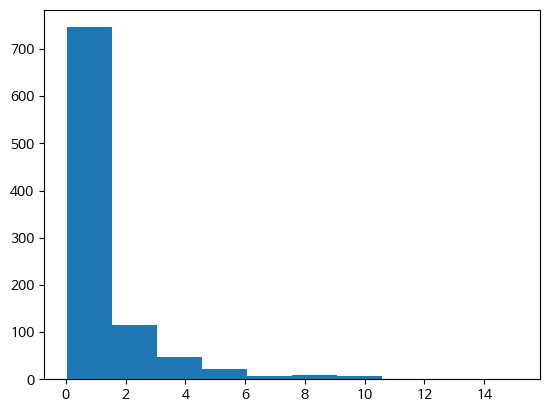

In [ ]:
plt.hist(num_of_reports_lower_25['tobin_Q'])

(array([1.0901e+04, 3.4800e+02, 6.5000e+01, 1.2000e+01, 1.5000e+01,
        5.0000e+00, 5.0000e+00, 1.0000e+00, 2.0000e+00, 4.0000e+00]),
 array([1.45633814e-02, 2.81624193e+00, 5.61792047e+00, 8.41959901e+00,
        1.12212776e+01, 1.40229561e+01, 1.68246346e+01, 1.96263132e+01,
        2.24279917e+01, 2.52296703e+01, 2.80313488e+01]),
 <BarContainer object of 10 artists>)

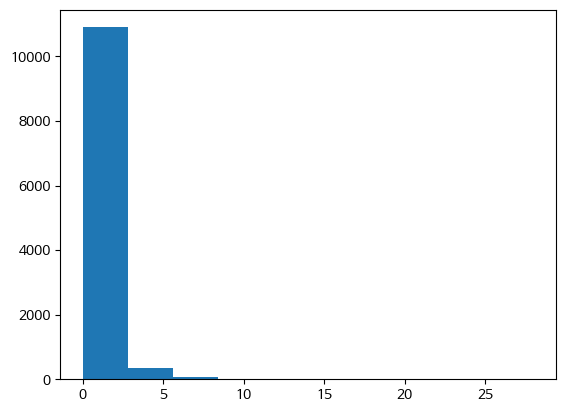

In [ ]:
plt.hist(num_of_reports_higher_25['tobin_Q'])

### 감성분석과의 관련성을 봐보자! (가설확인)

In [ ]:
num_of_reports_lower_25

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q
291,7.666025e+11,4.776607e+11,2.889419e+11,2.481156e+11,6.307202e+09,2025,11013,1분기보고서,2025-03-31,DS단석,17860,4.026785e+11,1.148364
292,7.524511e+11,4.695435e+11,2.829076e+11,2.217253e+11,-5.398949e+09,2025,11012,반기보고서,2025-06-30,DS단석,17860,4.431221e+11,1.212924
293,7.245176e+11,4.406755e+11,2.838421e+11,2.185394e+11,2.172129e+09,2024,11013,1분기보고서,2024-03-31,DS단석,17860,0.000000e+00,0.608233
294,7.302603e+11,4.441110e+11,2.861493e+11,2.663082e+11,1.991084e+09,2024,11012,반기보고서,2024-06-30,DS단석,17860,0.000000e+00,0.608154
295,7.244559e+11,4.410071e+11,2.834488e+11,2.591143e+11,-2.842442e+09,2024,11014,3분기보고서,2024-09-30,DS단석,17860,4.507420e+11,1.230923
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18211,8.409840e+10,4.883947e+10,3.525892e+10,1.674333e+10,5.278984e+08,2023,11013,1분기보고서,2023-03-31,화인써키트,127980,2.048195e+11,3.016217
18212,1.011284e+11,6.140664e+10,3.972175e+10,1.766304e+10,9.979045e+08,2023,11012,반기보고서,2023-06-30,화인써키트,127980,1.449195e+11,2.040239
18213,1.005210e+11,5.861576e+10,4.190526e+10,1.738562e+10,9.547073e+08,2023,11014,3분기보고서,2023-09-30,화인써키트,127980,0.000000e+00,0.583119
18214,1.057658e+11,5.754272e+10,4.822312e+10,6.922234e+10,5.207565e+09,2023,11011,사업보고서,2023-12-31,화인써키트,127980,0.000000e+00,0.544058


In [ ]:
num_of_reports_lower_25['종목코드'].unique()

array(['17860', '440290', '443060', '487570', '442770', '448760',
       '469480', '2550', '464680', '492220', '64400', '417200', '476080',
       '400760', '402340', '1510', '472230', '421800', '489210', '60000',
       '402490', '417010', '405920', '293580', '92790', '348340',
       '323350', '373160', '303810', '111380', '454910', '176750',
       '35430', '477760', '489730', '347850', '462510', '388790',
       '443250', '400', '474170', '60', '434480', '417970', '333050',
       '463480', '477380', '85620', '6800', '475460', '331520', '199480',
       '438700', '457600', '439580', '413640', '473370', '451250',
       '466410', '452430', '419120', '419050', '448730', '425290',
       '29780', '810', '482630', '452670', '1290', '411080', '378800',
       '31210', '188260', '318160', '415380', '418250', '462870',
       '162300', '290560', '472220', '487360', '487830', '32710', '88280',
       '109670', '450950', '460470', '461300', '368600', '464500',
       '212710', '462980', '11

In [ ]:
## DART쪽은 고유한 종목 175개, 뉴스크롤링을 통해 수집된 후보군 기업리스트는 90개 (뉴스쪽 수집된 후보군이 더 적음)
print(len(set(num_of_reports_lower_25['종목코드'].unique())),
len(set(num_of_reports_lower_25['종목코드'].unique()) - set(news_3key['종목코드'].unique())))

175 90


### 3개 이상 데이터자산 키워드 언급 뉴스 등등이 있는 DART 기업목

In [ ]:
hypo_lower_25_dart_news_df =\
num_of_reports_lower_25[num_of_reports_lower_25['종목코드'].isin(set(num_of_reports_lower_25['종목코드'].unique()) & set(news_3key['종목코드'].unique()))]

In [ ]:
hypo_higher_25_dart_news_df =\
num_of_reports_higher_25[num_of_reports_higher_25['종목코드'].isin(set(num_of_reports_higher_25['종목코드'].unique()) & set(news_3key['종목코드'].unique()))]

In [ ]:
hypo_lower_25_dart_news_df = hypo_lower_25_dart_news_df.reset_index(drop=True)
hypo_higher_25_dart_news_df = hypo_higher_25_dart_news_df.reset_index(drop=True)

### 1개 이상 데이터자산 키워드 언급 뉴스 등등이 있는 DART 기업목록

In [ ]:
hypo_lower_25_dart_news_df_key1 =\
num_of_reports_lower_25[num_of_reports_lower_25['종목코드'].isin(set(num_of_reports_lower_25['종목코드'].unique()) & set(news_1key['종목코드'].unique()))]

In [ ]:
hypo_higher_25_dart_news_df_key1 =\
num_of_reports_higher_25[num_of_reports_higher_25['종목코드'].isin(set(num_of_reports_higher_25['종목코드'].unique()) & set(news_1key['종목코드'].unique()))]

In [ ]:
hypo_lower_25_dart_news_df_key1 = hypo_lower_25_dart_news_df_key1.reset_index(drop=True)
hypo_higher_25_dart_news_df_key1 = hypo_higher_25_dart_news_df_key1.reset_index(drop=True)

### 회계정보 상위권의 뉴스 감성 정보 탐색

In [ ]:
news_3key['종목코드']=news_3key['종목코드'].astype(object)

In [ ]:
filtered_news_3key = news_3key[
    news_3key['종목코드'].astype(str).isin(
        hypo_higher_25_dart_news_df['종목코드'].astype(str).unique()
    )
]
filtered_news_3key

,종목명,종목코드,기사날짜,기사제목,기사링크,본문요약,긍정확률,부정확률,신뢰도,감성점수,...,탐지된종목코드,키워드소스,분석버전,GPU디바이스,처리시간,혼합정밀도,분석일시,기사년도,기사월,기사요일
858,BF랩스,139050,2024-12-12,"슈퍼캣, PIP 랩스와 업무협약...AI 기반 게임 개발 손 잡았다",https://www.techm.kr/news/articleView.html?idx...,"KT 무선망 '부실관리' 정황…""불법 기지국, 6월부터 활동 1만9000여명 접속""...",0.5749,0.4251,0.5749,0.1498,...,139050,dynamic,gpu_smart_v2.0,cuda:0,0.058594,Yes,2025-09-22 02:09:50,2024,12,3
907,휴맥스,115160,2024-12-31,"전자제품 상장기업 2024년 12월 브랜드평판... 1위 LG전자, 2위 아남전자...",https://www.thefairnews.co.kr/news/articleView...,"KB금융, 2025 'KB금융 코리아 스위밍 챔피언십' 타이틀 후원[더페어 프리즘]...",0.6079,0.3921,0.6079,0.2159,...,115160,dynamic,gpu_smart_v2.0,cuda:0,0.121614,Yes,2025-09-22 00:57:45,2024,12,1
908,휴맥스,115160,2024-11-28,[카&테크]휴맥스모빌리티 주차장으로 모빌리티 생태계 확장,https://n.news.naver.com/mnews/article/030/000...,제주도 서귀포 월드컵 경기장 'ESS 융복합 EV충전 스테이션'휴맥스모빌리티가 주차...,0.8340,0.1660,0.8340,0.6680,...,115160,dynamic,gpu_smart_v2.0,cuda:0,0.047373,No,2025-09-22 02:10:54,2024,11,3
909,휴맥스,115160,2024-01-22,"휴맥스모빌리티, 실내 주차장 내비 구현",https://n.news.naver.com/mnews/article/011/000...,정부세종청사 체육관 지하 주차장에 구축주차 관제와 비전 AI 등 결합[서울경제]휴맥...,0.6480,0.3520,0.6480,0.2960,...,115160,dynamic,gpu_smart_v2.0,cuda:0,0.039006,No,2025-09-22 02:15:19,2024,1,0
975,화인베스틸,133820,2024-09-04,"인포인·화인베스틸, 로봇기반 스마트빌딩 실현…'부산갈매기 1호' 도입",https://n.news.naver.com/mnews/article/421/000...,인포인 제공(서울=뉴스1) 장도민 기자 = 인포인은 로봇 기반 스마트빌딩 실증사업을...,0.4457,0.5543,0.5543,-0.1087,...,133820,dynamic,gpu_smart_v2.0,cuda:0,0.039439,No,2025-09-22 02:12:34,2024,9,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12682,강원에너지,114190,2024-07-10,"강원 수열에너지 융복합 클러스터, 데이터센터 유치 설명회 개최",https://n.news.naver.com/mnews/article/654/000...,"▲ 강원특별자치도는 K-water, 춘천시와 함께 10일 도청 제2별관에서 '강원 ...",0.5518,0.4482,0.5518,0.1036,...,114190,dynamic,gpu_smart_v2.0,cuda:0,0.037882,No,2025-09-22 02:13:22,2024,7,2
12683,강원에너지,114190,2024-07-10,강원 수열에너지 융복합 클러스터 데이터센터 유치설명회,https://n.news.naver.com/mnews/article/003/001...,"수자원공사, 강원도·춘천시…클라우드데이터센터(F1) 용지 분양[대전=뉴시스]곽상훈 ...",0.5389,0.4611,0.5389,0.0778,...,114190,dynamic,gpu_smart_v2.0,cuda:0,0.036929,No,2025-09-22 02:13:21,2024,7,2
12684,강원에너지,114190,2024-07-10,"수자원공사, 강원 수열에너지 융복합 클러스터 데이터센터 유치설명회...",https://news.mtn.co.kr/news-detail/20240710152...,"수자원공사, 강원 수열에너지 융복합 클러스터 데이터센터 유치설명회 실시이군호기자20...",0.5372,0.4628,0.5372,0.0743,...,114190,dynamic,gpu_smart_v2.0,cuda:0,0.037882,No,2025-09-22 02:13:22,2024,7,2
12685,강원에너지,114190,2024-07-10,강원자치도 강원 수열에너지 융복합 클러스터 데이터 유치 설명회 개최,https://n.news.naver.com/mnews/article/087/000...,"강원특별자치도와 K-water, 춘천시 등은 10일 오후 2시 강원특별자치도청 제2...",0.5188,0.4812,0.5188,0.0376,...,114190,dynamic,gpu_smart_v2.0,cuda:0,0.036929,No,2025-09-22 02:13:21,2024,7,2


In [ ]:
filtered_news_3key.to_csv("회계정보상위권_뉴스감성분석정보(개선판).csv",encoding='utf-8-sig')

In [ ]:
filtered_news_3key_lower = news_3key[
    news_3key['종목코드'].astype(str).isin(
        hypo_lower_25_dart_news_df['종목코드'].astype(str).unique()
    )
]
filtered_news_3key_lower

,종목명,종목코드,기사날짜,기사제목,기사링크,본문요약,긍정확률,부정확률,신뢰도,감성점수,...,탐지된종목코드,키워드소스,분석버전,GPU디바이스,처리시간,혼합정밀도,분석일시,기사년도,기사월,기사요일
82,SK스퀘어,402340,2024-12-05,"SK스퀘어, ‘CIO·포트폴리오매니지먼트’ 통합… 원스토어·티맵모빌리...",https://biz.newdaily.co.kr/site/data/html/2024...,01‘GTA6’ 출시일에 울고 웃는 게임업계 “마주치면 어쩌나”02“AI 데이터센터...,0.7070,0.2930,0.7070,0.4140,...,43610,dynamic,gpu_smart_v2.0,cuda:0,0.053860,Yes,2025-09-22 02:10:05,2024,12,3
83,SK스퀘어,402340,2024-12-05,"젊은 리더 전진배치 SK스퀘어, 원스토어·티맵·FSK L&S CEO 교체",https://n.news.naver.com/mnews/article/029/000...,"SK스퀘어 본사 T타워.SK스퀘어는 인공지능(AI), 반도체 등 미래 성장 분야 투...",0.6535,0.3465,0.6535,0.3071,...,402340,dynamic,gpu_smart_v2.0,cuda:0,0.103425,Yes,2025-09-22 02:10:07,2024,12,3
84,SK스퀘어,402340,2024-12-05,"SK스퀘어 AI·반도체 주력, 원스토어·티맵·FSK 등 CEO 교체",https://n.news.naver.com/mnews/article/008/000...,SK스퀘어 본사 T타워 / 사진제공=SK스퀘어SK스퀘어가 AI(인공지능)·반도체 등...,0.6319,0.3681,0.6319,0.2638,...,402340,dynamic,gpu_smart_v2.0,cuda:0,0.103856,Yes,2025-09-22 02:10:06,2024,12,3
85,SK스퀘어,402340,2024-11-15,[코스피·코스닥 14일 주요 공시] SK스퀘어 3분기 순익 분기 최대…“AI...,http://www.betanews.net:8080/article/1479465.html,▲SK스퀘어가 올해 3분기 연결 기준 영업이익 1조1620억원과 매출 4575억원을...,0.6542,0.3458,0.6542,0.3084,...,402340,dynamic,gpu_smart_v2.0,cuda:0,0.043321,No,2025-09-22 02:11:21,2024,11,4
86,SK스퀘어,402340,2024-11-14,"SK스퀘어 3분기 순이익 분기 최대…""AI 등 조 단위 투자 검토""",https://n.news.naver.com/mnews/article/001/001...,(서울=연합뉴스) 조성미 기자 = SK스퀘어가 지난 3분기 연결 기준 1조1천620...,0.8207,0.1793,0.8207,0.6414,...,402340,dynamic,gpu_smart_v2.0,cuda:0,0.040682,No,2025-09-22 02:11:22,2024,11,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12612,나노팀,417010,2024-01-26,"[VC는 지금]④""정직함으로 100년 기업 도전…올핸 '닥치고 AI' 투자""",https://n.news.naver.com/mnews/article/277/000...,국내 최초 VC 아주IB투자…올해 창립 50주년올해 지난해보다 1.5배 늘어난 30...,0.7806,0.2194,0.7806,0.5613,...,417010,dynamic,gpu_smart_v2.0,cuda:0,0.039646,No,2025-09-22 02:15:16,2024,1,4
12626,그린리소스,402490,2024-12-24,"[여의도 클라쓰] '그린리소스, 마음AI, 온코닉테라퓨틱스' 클라쓰 올릴 ...",https://news.mtn.co.kr/news-detail/20241224070...,"[여의도 클라쓰] '그린리소스, 마음AI, 온코닉테라퓨틱스' 클라쓰 올릴 종목은?[...",0.6002,0.3998,0.6002,0.2003,...,402490,dynamic,gpu_smart_v2.0,cuda:0,0.038460,Yes,2025-09-22 00:57:49,2024,12,1
12627,그린리소스,402490,2024-05-16,"[특징주] 그린리소스, 美 전력망 초전도케이블 설치 유도에 글로벌 기업...",https://n.news.naver.com/mnews/article/417/000...,그린리소스 주가가 강세다. 인공지능(AI) 데이터센터 열풍으로 미국 에너지 규제 당...,0.6224,0.3776,0.6224,0.2448,...,402490,dynamic,gpu_smart_v2.0,cuda:0,0.038558,No,2025-09-22 02:14:06,2024,5,3
12628,그린리소스,402490,2018-11-17,"구글, 클라우드 총괄 다이앤 그린 교체…오라클 사장 출신 영입",https://n.news.naver.com/mnews/article/001/001...,"""인공지능 무기화 논란에 사업도 선구자 명성에 못미치는 부진""(서울=연합뉴스) 김현...",0.2098,0.7902,0.7902,-0.5803,...,402490,dynamic,gpu_smart_v2.0,cuda:0,0.040745,No,2025-09-22 02:19:15,2018,11,5


In [ ]:
filtered_news_3key_lower.to_csv("회계정보하위권_뉴스감성분석정보(개선판).csv",encoding='utf-8-sig')

### 가설 검정용 DF 생성

In [ ]:
news_1key.to_csv("데이터자산_1회이상언급_기사전체목록.csv",encoding='utf-8-sig')

In [ ]:
# news_3key.to_csv("데이터자산_3회이상언급_기사전체목록.csv",encoding='utf-8-sig')

In [ ]:
news_3key.to_csv("데이터자산_3회이상언급_기사전체목록(개선).csv",encoding='utf-8-sig')

In [ ]:
news_3key['긍정확률']

,긍정확률
0,0.3578
1,0.3578
2,0.6280
3,0.4751
4,0.7428
...,...
13333,0.7428
13334,0.6478
13335,0.5281
13336,0.4073


In [ ]:
np.nanstd([1,2,3,3,3])

np.float64(0.8)

In [ ]:
news_3key[(news_3key['기사년도']==int(year))&(news_3key['종목코드']==str(code))]

,종목명,종목코드,기사날짜,기사제목,기사링크,긍정확률,부정확률,대상기업,산업분류,분석일시,감성분류,기사년도,기사월,기사요일


In [ ]:
code

'127980'

In [ ]:
news_3key[(news_3key['종목코드']==code)]

,종목명,종목코드,기사날짜,기사제목,기사링크,긍정확률,부정확률,대상기업,산업분류,분석일시,감성분류,기사년도,기사월,기사요일
7223,화인써키트,127980,2024-01-23,"[경이로운 소문] 빅테크, AI 열풍에 ‘데이터센터 확충’… 관련주도 매...",https://news.mtn.co.kr/news-detail/20240123145...,0.5239,0.4761,화인써키트,일반,2025-09-20 16:14:19,긍정,2024,1,1
9224,화인써키트,127980,2023-06-21,"바이오 지고 'AI·XR' 뜨는 IPO 시장...""테마성 유의 필요""",https://www.ajunews.com/view/20230621161830699,0.2954,0.7046,화인써키트,일반,2025-09-20 16:14:41,부정,2023,6,2
9350,화인써키트,127980,2023-05-31,기판株 '반도체 호조·AI 붐' 타고 상승기류,https://n.news.naver.com/mnews/article/011/000...,0.6094,0.3906,화인써키트,일반,2025-09-20 16:09:37,긍정,2023,5,2


In [ ]:
news_3key

,종목명,종목코드,기사날짜,기사제목,기사링크,긍정확률,부정확률,대상기업,산업분류,분석일시,감성분류,기사년도,기사월,기사요일
0,휴맥스,115160,2024-12-31,"전자제품 상장기업 2024년 12월 브랜드평판... 1위 LG전자, 2위 아남전자...",https://www.thefairnews.co.kr/news/articleView...,0.3578,0.6422,휴맥스,일반,2025-09-20 16:15:51,부정,2024,12,1
1,휴림로봇,090710,2024-12-31,"로봇 상장기업 2024년 12월 브랜드평판... 1위 두산, 2위 신성델타테크,...",https://www.thefairnews.co.kr/news/articleView...,0.3578,0.6422,휴림로봇,일반,2025-09-20 16:15:51,부정,2024,12,1
2,아이앤씨,052860,2024-12-31,"신세계아이앤씨, ‘스파로스 CMP’ 국가정보원 주관 보안기능 확인서 획...",https://www.healthinnews.co.kr/view.php?ud=202...,0.6280,0.3720,아이앤씨,일반,2025-09-20 16:15:13,긍정,2024,12,1
3,아이앤씨,052860,2024-12-31,"신세계아이앤씨, 국정원 보안기능 확인서 획득",https://n.news.naver.com/mnews/article/016/000...,0.4751,0.5249,아이앤씨,일반,2025-09-20 16:10:23,부정,2024,12,1
4,아이앤씨,052860,2024-12-31,"신세계아이앤씨, '스파로스 CMP' 국가정보원 주관 보안기능 확인서 획득",http://www.itdaily.kr/news/articleView.html?id...,0.7428,0.2572,아이앤씨,일반,2025-09-20 16:07:03,긍정,2024,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13333,데이터스트림즈,199150,2015-04-01,[만나봅시다] 이영상 데이터스트림즈 대표이사,http://www.itdaily.kr/news/articleView.html?id...,0.7428,0.2572,데이터스트림즈,일반,2025-09-20 16:07:03,긍정,2015,4,2
13334,씨이랩,189330,2015-03-05,"씨이랩, 호튼웍스 자격증 과정 국내 도입",https://www.widedaily.com/news/articleView.htm...,0.6478,0.3522,씨이랩,일반,2025-09-20 16:16:01,긍정,2015,3,3
13335,데이터스트림즈,199150,2015-03-03,[창조경제의 힘-코넥스 테크리더]<4>빅데이터 매니지먼트 전문 기업 `데...,https://n.news.naver.com/mnews/article/030/000...,0.5281,0.4719,데이터스트림즈,일반,2025-09-20 16:11:22,긍정,2015,3,1
13336,브이엠,089970,2015-02-04,"브이엠웨어, 소프트웨어 정의 데이터센터 위한 신제품 출시",https://n.news.naver.com/mnews/article/014/000...,0.4073,0.5927,브이엠,일반,2025-09-20 16:09:43,부정,2015,2,2


### 고정효과 (통제변수) 탐색을 위한 EDA

>>> 자산 규모 통제변수에 추가

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder

LabelEncoder()

In [ ]:
hypo_higher_25_dart_news_df['자산총계'].apply(lambda x : np.log(x)).sort_values(ascending=False)

,자산총계
819,29.103468
820,29.097628
824,29.067808
823,29.056608
822,29.020509
...,...
534,23.258532
542,23.255342
544,23.238990
537,23.203767


In [ ]:
print(np.log(hypo_lower_25_dart_news_df['자산총계']).min(),np.log(hypo_lower_25_dart_news_df['자산총계']).max())

21.41361382692534 30.831411574331447


In [ ]:
# 로그 변환
log_asset_higher = np.log(hypo_higher_25_dart_news_df['자산총계'])
log_asset_lower = np.log(hypo_lower_25_dart_news_df['자산총계'])

# 각 그룹별 사분위수 구간 경계값 (0%,25%,50%,75%,100%)
bins_higher = log_asset_higher.quantile([0, 0.25, 0.5, 0.75, 1]).values
bins_lower = log_asset_lower.quantile([0, 0.25, 0.5, 0.75, 1]).values

# 라벨 정의 (4구간)
labels = ['Q1 (0~25%)', 'Q2 (25~50%)', 'Q3 (50~75%)', 'Q4 (75~100%)']

# 구간으로 자산규모군집 생성 (right=False: 왼쪽 포함, 오른쪽 미포함)
hypo_higher_25_dart_news_df['자산규모군집'] = pd.cut(log_asset_higher, bins=bins_higher, labels=labels, right=False, include_lowest=True)
hypo_lower_25_dart_news_df['자산규모군집'] = pd.cut(log_asset_lower, bins=bins_lower, labels=labels, right=False, include_lowest=True)

# 라벨을 수치로 변환 (LabelEncoder 사용)
encoder_higher = LabelEncoder()
encoder_lower = LabelEncoder()

hypo_higher_25_dart_news_df['자산규모변수'] = encoder_higher.fit_transform(hypo_higher_25_dart_news_df['자산규모군집'])
hypo_lower_25_dart_news_df['자산규모변수'] = encoder_lower.fit_transform(hypo_lower_25_dart_news_df['자산규모군집'])

# 결과 출력 예시
print(hypo_higher_25_dart_news_df[['자산총계', '자산규모군집', '자산규모변수']].head())
print(hypo_lower_25_dart_news_df[['자산총계', '자산규모군집', '자산규모변수']].head())

           자산총계      자산규모군집  자산규모변수
0  3.800930e+10  Q1 (0~25%)       0
1  3.765791e+10  Q1 (0~25%)       0
2  6.409013e+10  Q1 (0~25%)       0
3  6.019347e+10  Q1 (0~25%)       0
4  5.321868e+10  Q1 (0~25%)       0
           자산총계       자산규모군집  자산규모변수
0  9.229825e+10  Q3 (50~75%)       2
1  9.072643e+10  Q3 (50~75%)       2
2  9.024179e+10  Q3 (50~75%)       2
3  8.756279e+10  Q3 (50~75%)       2
4  9.057374e+10  Q3 (50~75%)       2


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 로그 변환
log_asset_higher_key1 = np.log(hypo_higher_25_dart_news_df_key1['자산총계'])
log_asset_lower_key1 = np.log(hypo_lower_25_dart_news_df_key1['자산총계'])

# 사분위수 경계값 생성
bins_higher_key1 = log_asset_higher_key1.quantile([0, 0.25, 0.5, 0.75, 1]).values
bins_lower_key1 = log_asset_lower_key1.quantile([0, 0.25, 0.5, 0.75, 1]).values

# 라벨 정의
labels = ['Q1 (0~25%)', 'Q2 (25~50%)', 'Q3 (50~75%)', 'Q4 (75~100%)']

# 군집 생성
hypo_higher_25_dart_news_df_key1['자산규모군집'] = pd.cut(log_asset_higher_key1, bins=bins_higher_key1, labels=labels, right=False, include_lowest=True)
hypo_lower_25_dart_news_df_key1['자산규모군집'] = pd.cut(log_asset_lower_key1, bins=bins_lower_key1, labels=labels, right=False, include_lowest=True)

# 수치형 변수 변환
encoder_higher_key1 = LabelEncoder()
encoder_lower_key1 = LabelEncoder()

hypo_higher_25_dart_news_df_key1['자산규모변수'] = encoder_higher_key1.fit_transform(hypo_higher_25_dart_news_df_key1['자산규모군집'])
hypo_lower_25_dart_news_df_key1['자산규모변수'] = encoder_lower_key1.fit_transform(hypo_lower_25_dart_news_df_key1['자산규모군집'])

# 확인 출력
print(hypo_higher_25_dart_news_df_key1[['자산총계', '자산규모군집', '자산규모변수']].head())
print(hypo_lower_25_dart_news_df_key1[['자산총계', '자산규모군집', '자산규모변수']].head())

           자산총계      자산규모군집  자산규모변수
0  3.800930e+10  Q1 (0~25%)       0
1  3.765791e+10  Q1 (0~25%)       0
2  6.409013e+10  Q1 (0~25%)       0
3  6.019347e+10  Q1 (0~25%)       0
4  5.321868e+10  Q1 (0~25%)       0
           자산총계       자산규모군집  자산규모변수
0  9.229825e+10  Q3 (50~75%)       2
1  9.072643e+10  Q3 (50~75%)       2
2  9.024179e+10  Q3 (50~75%)       2
3  8.756279e+10  Q3 (50~75%)       2
4  9.057374e+10  Q3 (50~75%)       2


In [ ]:
hypo_lower_25_dart_news_df

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q,자산규모군집,자산규모변수
0,9.229825e+10,9.927992e+09,8.237025e+10,2.370298e+09,4.441387e+08,2025,11013,1분기보고서,2025-03-31,HB인베스트먼트,440290,4.483499e+10,0.593326,Q3 (50~75%),2
1,9.072643e+10,5.111851e+09,8.561458e+10,6.576917e+09,3.244327e+09,2025,11012,반기보고서,2025-06-30,HB인베스트먼트,440290,5.760240e+10,0.691246,Q3 (50~75%),2
2,9.024179e+10,7.409952e+09,8.283184e+10,4.922298e+09,1.868042e+09,2024,11013,1분기보고서,2024-03-31,HB인베스트먼트,440290,0.000000e+00,0.082112,Q3 (50~75%),2
3,8.756279e+10,4.408507e+09,8.315428e+10,1.997430e+09,-2.470521e+07,2024,11012,반기보고서,2024-06-30,HB인베스트먼트,440290,0.000000e+00,0.050347,Q3 (50~75%),2
4,9.057374e+10,4.749012e+09,8.582473e+10,3.539328e+09,2.670445e+09,2024,11014,3분기보고서,2024-09-30,HB인베스트먼트,440290,5.421402e+10,0.650995,Q3 (50~75%),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,8.409840e+10,4.883947e+10,3.525892e+10,1.674333e+10,5.278984e+08,2023,11013,1분기보고서,2023-03-31,화인써키트,127980,2.048195e+11,3.016217,Q3 (50~75%),2
548,1.011284e+11,6.140664e+10,3.972175e+10,1.766304e+10,9.979045e+08,2023,11012,반기보고서,2023-06-30,화인써키트,127980,1.449195e+11,2.040239,Q3 (50~75%),2
549,1.005210e+11,5.861576e+10,4.190526e+10,1.738562e+10,9.547073e+08,2023,11014,3분기보고서,2023-09-30,화인써키트,127980,0.000000e+00,0.583119,Q3 (50~75%),2
550,1.057658e+11,5.754272e+10,4.822312e+10,6.922234e+10,5.207565e+09,2023,11011,사업보고서,2023-12-31,화인써키트,127980,0.000000e+00,0.544058,Q3 (50~75%),2


In [ ]:
hypo_higher_25_dart_news_df

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q,자산규모군집,자산규모변수
0,3.800930e+10,1.904721e+10,1.896209e+10,3.942873e+09,-1.324420e+09,2025,11013,1분기보고서,2025-03-31,BF랩스,139050,2.424797e+10,1.139068,Q1 (0~25%),0
1,3.765791e+10,1.949169e+10,1.816622e+10,3.820003e+09,-8.056001e+08,2025,11012,반기보고서,2025-06-30,BF랩스,139050,2.424797e+10,1.161500,Q1 (0~25%),0
2,6.409013e+10,2.441251e+10,3.967762e+10,5.157237e+09,-6.179555e+09,2024,11013,1분기보고서,2024-03-31,BF랩스,139050,0.000000e+00,0.380909,Q1 (0~25%),0
3,6.019347e+10,2.434674e+10,3.584673e+10,4.273630e+09,-3.695075e+09,2024,11012,반기보고서,2024-06-30,BF랩스,139050,0.000000e+00,0.404475,Q1 (0~25%),0
4,5.321868e+10,1.996150e+10,3.325718e+10,4.241528e+09,-2.402585e+09,2024,11014,3분기보고서,2024-09-30,BF랩스,139050,2.424797e+10,0.830713,Q1 (0~25%),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,9.329871e+11,4.359132e+11,4.970740e+11,3.090275e+11,6.432959e+09,2016,11013,1분기보고서,2016-03-31,휴맥스,115160,3.144401e+11,0.804248,Q4 (75~100%),3
971,9.156918e+11,4.034938e+11,5.121980e+11,3.076114e+11,1.198004e+10,2016,11012,반기보고서,2016-06-30,휴맥스,115160,3.252005e+11,0.795786,Q4 (75~100%),3
972,9.268727e+11,4.457736e+11,4.810991e+11,3.331006e+11,-7.894580e+09,2016,11014,3분기보고서,2016-09-30,휴맥스,115160,3.467211e+11,0.855020,Q4 (75~100%),3
973,1.018356e+12,5.480072e+11,4.703484e+11,1.350510e+12,3.247962e+09,2016,11011,사업보고서,2016-12-31,휴맥스,115160,0.000000e+00,0.538130,Q4 (75~100%),3


{'whiskers': [<matplotlib.lines.Line2D at 0x7a0b4db9a720>,
 'caps': [<matplotlib.lines.Line2D at 0x7a0b4db9b3e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a0b4db9a1e0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a0b4db9bc80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a0b4dba5790>],
 'means': []}

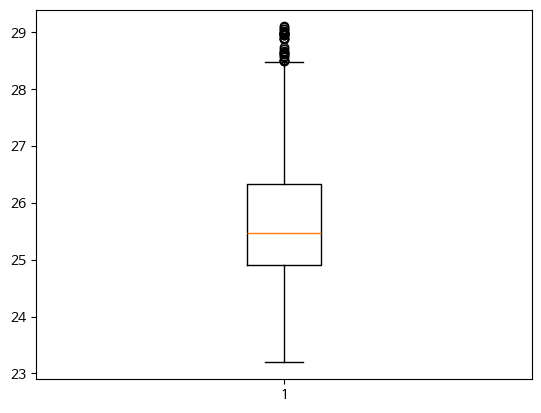

In [ ]:
plt.boxplot(hypo_higher_25_dart_news_df['자산총계'].apply(lambda x : np.log(x)))

In [ ]:
# 결과를 담을 리스트
results = []

for year in hypo_higher_25_dart_news_df['bsns_year'].unique():
    temp_year = hypo_higher_25_dart_news_df[hypo_higher_25_dart_news_df['bsns_year'] == year]
    for code in hypo_higher_25_dart_news_df['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
            '자산규모군집' : temp['자산규모군집'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_high25 = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_high25)

/tmp/ipython-input-2521640477.py:16: RuntimeWarning: Mean of empty slice
  '긍정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipython-input-2521640477.py:19: RuntimeWarning: Mean of empty slice
  '부정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),


       년도    종목코드       기업명        자산규모군집  Tobin_Q(평균)  긍정점수평균  긍정점수중위수  \
0    2015  101140     인바이오젠    Q1 (0~25%)     0.464266     NaN      NaN   
1    2015  103590      일진전기  Q4 (75~100%)     0.563158     NaN      NaN   
2    2015  106520     노블엠앤비   Q3 (50~75%)     0.464129     NaN      NaN   
3    2015  109070   주성코퍼레이션   Q2 (25~50%)     0.822181     NaN      NaN   
4    2015  114190     강원에너지   Q2 (25~50%)     0.337871     NaN      NaN   
..    ...     ...       ...           ...          ...     ...      ...   
270  2025  200710  에이디테크놀로지   Q3 (50~75%)     1.366026     NaN      NaN   
271  2025  206400     베노티앤알   Q2 (25~50%)     0.834359     NaN      NaN   
272  2025  208710        포톤   Q2 (25~50%)     0.835300     NaN      NaN   
273  2025  215200   메가스터디교육  Q4 (75~100%)     1.012712     NaN      NaN   
274  2025  222800        심텍  Q4 (75~100%)     1.183835     NaN      NaN   

     긍정점수표준편차  부정점수평균  부정점수중위수  부정점수표준편차  
0         NaN     NaN      NaN       NaN  
1         NaN

In [ ]:
# 결과를 담을 리스트
results = []

for year in hypo_higher_25_dart_news_df_key1['bsns_year'].unique():
    temp_year = hypo_higher_25_dart_news_df_key1[hypo_higher_25_dart_news_df_key1['bsns_year'] == year]
    for code in hypo_higher_25_dart_news_df_key1['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
            '자산규모군집' : temp['자산규모군집'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_high25_key1 = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_high25_key1)

/tmp/ipython-input-1870044893.py:16: RuntimeWarning: Mean of empty slice
  '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipython-input-1870044893.py:19: RuntimeWarning: Mean of empty slice
  '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),


       년도    종목코드      기업명        자산규모군집  Tobin_Q(평균)  긍정점수평균  긍정점수중위수  \
0    2015  100130    동국S&C  Q4 (75~100%)     0.313755     NaN      NaN   
1    2015  101140    인바이오젠    Q1 (0~25%)     0.464266     NaN      NaN   
2    2015  103590     일진전기  Q4 (75~100%)     0.563158     NaN      NaN   
3    2015  104460  디와이피엔에프   Q2 (25~50%)     0.391854     NaN      NaN   
4    2015  106520    노블엠앤비   Q3 (50~75%)     0.464129     NaN      NaN   
..    ...     ...      ...           ...          ...     ...      ...   
446  2025  215200  메가스터디교육  Q4 (75~100%)     1.012712     NaN      NaN   
447  2025  217190      제너셈   Q2 (25~50%)     1.172686     NaN      NaN   
448  2025  219130    타이거일렉   Q2 (25~50%)     1.256127     NaN      NaN   
449  2025  222420      쎄노텍   Q2 (25~50%)     1.030186     NaN      NaN   
450  2025  222800       심텍  Q4 (75~100%)     1.183835     NaN      NaN   

     긍정점수표준편차  부정점수평균  부정점수중위수  부정점수표준편차  
0         NaN     NaN      NaN       NaN  
1         NaN     NaN    

In [ ]:
# 결과를 담을 리스트
results = []

for year in hypo_lower_25_dart_news_df['bsns_year'].unique():
    temp_year = hypo_lower_25_dart_news_df[hypo_lower_25_dart_news_df['bsns_year'] == year]
    for code in hypo_lower_25_dart_news_df['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
              '자산규모군집' : temp['자산규모군집'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_low25 = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_low25)

/tmp/ipython-input-230020103.py:16: RuntimeWarning: Mean of empty slice
  '긍정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipython-input-230020103.py:19: RuntimeWarning: Mean of empty slice
  '부정점수평균': np.nanmean(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['부정확률']),
/tmp/ipython-input-230020103.py:17: RuntimeWarning: All-NaN slice encountered
  '긍정점수중위수': np.nanmedian(news_3key[(news_3key['기사년도']==year)&(news_3key['종목코드']==code)]['긍정확률']),
/tmp/ipython-input-230020103.py:20: RuntimeWarning: All-NaN slice encountered
  '부정점수중위수': np.nanmedian(news_3key[(news_3key[

       년도    종목코드          기업명        자산규모군집  Tobin_Q(평균)  긍정점수평균  긍정점수중위수  \
0    2020  357120  코람코라이프인프라리츠  Q4 (75~100%)     0.661895     NaN      NaN   
1    2021  357120  코람코라이프인프라리츠  Q4 (75~100%)     0.849104     NaN      NaN   
2    2021  400760       NH올원리츠  Q4 (75~100%)     0.612842     NaN      NaN   
3    2022  127980        화인써키트   Q2 (25~50%)          NaN     NaN      NaN   
4    2022  168360          펨트론   Q3 (50~75%)     0.640736     NaN      NaN   
..    ...     ...          ...           ...          ...     ...      ...   
214  2025  482630        삼양엔씨켐  Q4 (75~100%)     1.527048     NaN      NaN   
215  2025  487360     신한제14호스팩    Q1 (0~25%)     1.065498     NaN      NaN   
216  2025  487830     신한제15호스팩    Q1 (0~25%)     1.047990     NaN      NaN   
217  2025  489210      교보17호스팩    Q1 (0~25%)     1.011118     NaN      NaN   
218  2025  498390   한화플러스제5호스팩    Q1 (0~25%)     1.013222     NaN      NaN   

     긍정점수표준편차  부정점수평균  부정점수중위수  부정점수표준편차  
0         NaN     Na

In [ ]:
# 결과를 담을 리스트
results = []

for year in hypo_lower_25_dart_news_df_key1['bsns_year'].unique():
    temp_year = hypo_lower_25_dart_news_df_key1[hypo_lower_25_dart_news_df_key1['bsns_year'] == year]
    for code in hypo_lower_25_dart_news_df_key1['종목코드'].unique():
        temp = temp_year[temp_year['종목코드'] == code]
        if len(temp) == 0:   # 해당 연도에 데이터가 없으면 skip
            continue
        results.append({
            '년도': year,
            '종목코드': code,
            '기업명': temp['기업명'].iloc[0],
            '자산규모군집' : temp['자산규모군집'].iloc[0],
            'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),
            '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '긍정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
            '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수중위수': np.nanmedian(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
            '부정점수표준편차': np.nanstd(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률'])
        })

# 최종 DataFrame 생성
tobin_df_low25_key1 = pd.DataFrame(results).sort_values(['년도', '종목코드']).reset_index(drop=True)

# 결과 확인
print(tobin_df_low25_key1)

/tmp/ipython-input-251511922.py:16: RuntimeWarning: Mean of empty slice
  '긍정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['긍정확률']),
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipython-input-251511922.py:19: RuntimeWarning: Mean of empty slice
  '부정점수평균': np.nanmean(news_1key[(news_1key['기사년도']==year)&(news_1key['종목코드']==code)]['부정확률']),
/tmp/ipython-input-251511922.py:15: RuntimeWarning: Mean of empty slice
  'Tobin_Q(평균)': np.nanmean(temp['tobin_Q']),


       년도    종목코드          기업명        자산규모군집  Tobin_Q(평균)   긍정점수평균  긍정점수중위수  \
0    2020  357120  코람코라이프인프라리츠  Q4 (75~100%)     0.661895      NaN      NaN   
1    2021  357120  코람코라이프인프라리츠  Q4 (75~100%)     0.849104      NaN      NaN   
2    2021  400760       NH올원리츠  Q4 (75~100%)     0.612842  0.29585  0.29585   
3    2022  127980        화인써키트   Q2 (25~50%)          NaN      NaN      NaN   
4    2022  168360          펨트론   Q3 (50~75%)     0.640736      NaN      NaN   
..    ...     ...          ...           ...          ...      ...      ...   
281  2025  489210      교보17호스팩    Q1 (0~25%)     1.011118      NaN      NaN   
282  2025  489480     키움제11호스팩    Q1 (0~25%)     1.147038      NaN      NaN   
283  2025  489730   디비금융제13호스팩    Q1 (0~25%)     1.013265      NaN      NaN   
284  2025  493790    유안타제17호스팩    Q1 (0~25%)     1.012876      NaN      NaN   
285  2025  498390   한화플러스제5호스팩    Q1 (0~25%)     1.013222      NaN      NaN   

     긍정점수표준편차   부정점수평균  부정점수중위수  부정점수표준편차  
0      

In [ ]:
hypo_higher_25_dart_news_df.to_csv("회계정보상위권_기업가치및재무정보.csv",encoding='utf-8-sig')

In [ ]:
hypo_lower_25_dart_news_df.to_csv("회계정보하위권_기업가치및재무정보.csv",encoding='utf-8-sig')

In [ ]:
hypo_higher_25_dart_news_df_key1.to_csv("회계정보상위권_기업가치및재무정보_key1.csv",encoding='utf-8-sig')

In [ ]:
hypo_lower_25_dart_news_df_key1.to_csv("회계정보하위권_기업가치및재무정보_key1.csv",encoding='utf-8-sig')

### 가설2 통계검정

### box plot

In [ ]:
hypo_higher_25_dart_news_df

,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q,자산규모군집,자산규모변수
0,3.800930e+10,1.904721e+10,1.896209e+10,3.942873e+09,-1.324420e+09,2025,11013,1분기보고서,2025-03-31,BF랩스,139050,2.424797e+10,1.139068,Q1 (0~25%),0
1,3.765791e+10,1.949169e+10,1.816622e+10,3.820003e+09,-8.056001e+08,2025,11012,반기보고서,2025-06-30,BF랩스,139050,2.424797e+10,1.161500,Q1 (0~25%),0
2,6.409013e+10,2.441251e+10,3.967762e+10,5.157237e+09,-6.179555e+09,2024,11013,1분기보고서,2024-03-31,BF랩스,139050,0.000000e+00,0.380909,Q1 (0~25%),0
3,6.019347e+10,2.434674e+10,3.584673e+10,4.273630e+09,-3.695075e+09,2024,11012,반기보고서,2024-06-30,BF랩스,139050,0.000000e+00,0.404475,Q1 (0~25%),0
4,5.321868e+10,1.996150e+10,3.325718e+10,4.241528e+09,-2.402585e+09,2024,11014,3분기보고서,2024-09-30,BF랩스,139050,2.424797e+10,0.830713,Q1 (0~25%),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,9.329871e+11,4.359132e+11,4.970740e+11,3.090275e+11,6.432959e+09,2016,11013,1분기보고서,2016-03-31,휴맥스,115160,3.144401e+11,0.804248,Q4 (75~100%),3
971,9.156918e+11,4.034938e+11,5.121980e+11,3.076114e+11,1.198004e+10,2016,11012,반기보고서,2016-06-30,휴맥스,115160,3.252005e+11,0.795786,Q4 (75~100%),3
972,9.268727e+11,4.457736e+11,4.810991e+11,3.331006e+11,-7.894580e+09,2016,11014,3분기보고서,2016-09-30,휴맥스,115160,3.467211e+11,0.855020,Q4 (75~100%),3
973,1.018356e+12,5.480072e+11,4.703484e+11,1.350510e+12,3.247962e+09,2016,11011,사업보고서,2016-12-31,휴맥스,115160,0.000000e+00,0.538130,Q4 (75~100%),3


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler

# ===============================
# 1. 데이터 로드
# ===============================
low_val  = pd.read_csv("/content/회계정보하위권_기업가치및재무정보.csv")
high_val = pd.read_csv("/content/회계정보상위권_기업가치및재무정보.csv")
low_news = pd.read_csv("/content/회계정보하위권_뉴스감성분석정보.csv")
high_news= pd.read_csv("/content/회계정보상위권_뉴스감성분석정보.csv")

low_val = low_val#[low_val['bsns_year']>=2021]
high_val = high_val#[high_val['bsns_year']>=2021]
low_news = low_news#[low_news['기사년도'] >= 2021]
high_news = high_news#[high_news['기사년도'] >= 2021]

# ===============================
# 2. 연도별 집계 (기업×연도 단위)
# ===============================
low_news_grp = (
    low_news.groupby(["대상기업","기사년도"])["긍정확률"]
    .mean().reset_index()
)
high_news_grp = (
    high_news.groupby(["대상기업","기사년도"])["긍정확률"]
    .mean().reset_index()
)

low_val_grp = (
    low_val.groupby(["기업명","bsns_year"])[["tobin_Q","자산총계"]]
    .mean().reset_index()
)
high_val_grp = (
    high_val.groupby(["기업명","bsns_year"])[["tobin_Q","자산총계"]]
    .mean().reset_index()
)

# ===============================
# 3. 병합 및 그룹 라벨
# ===============================
low_df = pd.merge(
    low_val_grp, low_news_grp,
    left_on=["기업명","bsns_year"],
    right_on=["대상기업","기사년도"],
    how="inner"
)
low_df["info_group"] = 1  # 회계정보 하위

high_df = pd.merge(
    high_val_grp, high_news_grp,
    left_on=["기업명","bsns_year"],
    right_on=["대상기업","기사년도"],
    how="inner"
)
high_df["info_group"] = 0  # 회계정보 상위

full_df = pd.concat([low_df, high_df], ignore_index=True)

# ===============================
# 4. 변수 정리 및 결측 제거
# ===============================
full_df.rename(columns={
    "tobin_Q": "tobin_q",
    "긍정확률": "sentiment_mean",
    "bsns_year": "year",
    "자산총계": "total_assets"    # 새로 추가된 변수 이름 통일
}, inplace=True)

full_df = full_df[["tobin_q","sentiment_mean","info_group","year","total_assets"]].dropna()
full_df["year"] = pd.to_numeric(full_df["year"], errors="coerce")
full_df = full_df.dropna(subset=["year"])

# ===============================
# 5. 변수 스케일링 & 중심화
# ===============================
full_df["year_center"] = full_df["year"] - full_df["year"].mean()

scaler = MinMaxScaler()
full_df["sentiment_scaled"] = scaler.fit_transform(full_df[["sentiment_mean"]])

# 자산규모도 MinMax 스케일링하여 통제변수로 반영 (추가된 부분)
full_df["assets_scaled"] = scaler.fit_transform(full_df[["total_assets"]])

# ===============================
# 6. 표본 확인
# ===============================
print("데이터 크기:", full_df.shape)
print(full_df.head())

# ===============================
# 7. 1차: 기본 OLS 적합 (자산규모 통제변수 추가) - 변경 부분
# ===============================
# 기존 formula에 + assets_scaled 추가
formula = "tobin_q ~ sentiment_scaled * info_group + assets_scaled + year_center"
ols_basic = smf.ols(formula, data=full_df).fit()
print("\n[1차 OLS 기본 결과]")
print(ols_basic.summary())

# ===============================
# 8. 진단: 기술통계
# ===============================
print("\n기술통계\n", full_df[["tobin_q","sentiment_scaled","info_group","assets_scaled","year_center"]].describe())
print("\n연도별 관측치\n", full_df.groupby("year").size())

# ===============================
# 9. 2차: 강건(HC3) 추정 (자산규모 통제 유지) - 변경 부분
# ===============================
ols_robust = smf.ols(formula, data=full_df).fit(cov_type="HC3")
print("\n[2차 OLS 강건(HC3) 결과]")
print(ols_robust.summary())

# ===============================
# 10. 해석 가이드
# ===============================
print("""
해석 키포인트:
- sentiment_scaled:info_group 계수(p<0.05)
  → 회계정보가 부족한 기업에서 뉴스 감성(Tobin Q) 영향이 유의하게 다르다면 H1 채택
- assets_scaled: 자산규모가 기업가치에 미치는 영향 통제
- year_center: 장기 추세 통제
""")


데이터 크기: (130, 8)
    tobin_q  sentiment_mean  info_group  year  total_assets  year_center  \
1  1.783412        0.627400           1  2024  1.109062e+12     0.815385   
2  0.377485        0.595400           1  2024  1.010642e+10     0.815385   
3  1.446776        0.517614           1  2024  2.545081e+11     0.815385   
4  1.382304        0.357800           1  2024  6.660202e+10     0.815385   
5  0.835771        0.357700           1  2023  6.940865e+11    -0.184615   

   sentiment_scaled  assets_scaled  
1          0.773637       0.055581  
2          0.710867       0.000151  
3          0.558286       0.012478  
4          0.244802       0.003001  
5          0.244606       0.034650  

[1차 OLS 기본 결과]
                            OLS Regression Results                            
Dep. Variable:                tobin_q   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler

# ----------------------------------------------------
# 1. 데이터 로드 및 전처리
# ----------------------------------------------------
low_val  = pd.read_csv("/content/회계정보하위권_기업가치및재무정보.csv")
high_val = pd.read_csv("/content/회계정보상위권_기업가치및재무정보.csv")
low_news = pd.read_csv("/content/회계정보하위권_뉴스감성분석정보.csv")
high_news= pd.read_csv("/content/회계정보상위권_뉴스감성분석정보.csv")

# 분석연도 필터
YEAR_MIN = 2021
low_val  = low_val[low_val['bsns_year']  >= YEAR_MIN]
high_val = high_val[high_val['bsns_year'] >= YEAR_MIN]
low_news = low_news[low_news['기사년도']    >= YEAR_MIN]
high_news= high_news[high_news['기사년도'] >= YEAR_MIN]

def make_group(val_df, news_df, label):
    """기업×연도 Tobin Q와 뉴스감성 집계 후 병합"""
    val_grp = (
        val_df.groupby(["기업명","bsns_year"])["tobin_Q"]
        .mean().reset_index()
    )
    news_grp = (
        news_df.groupby(["대상기업","기사년도"])["긍정확률"]
        .mean().reset_index()
    )
    df = pd.merge(
        val_grp, news_grp,
        left_on=["기업명","bsns_year"],
        right_on=["대상기업","기사년도"],
        how="inner"
    )
    df.rename(columns={
        "tobin_Q":"tobin_q",
        "긍정확률":"sentiment",
        "bsns_year":"year"
    }, inplace=True)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df.dropna(subset=["tobin_q","sentiment","year"], inplace=True)

    # 연도 중심화
    df["year_c"] = df["year"] - df["year"].mean()

    # 감성 점수 MinMax 스케일링
    scaler = MinMaxScaler()
    df["sentiment_s"] = scaler.fit_transform(df[["sentiment"]])

    df["group"] = label
    return df

low_df  = make_group(low_val,  low_news,  "low")
high_df = make_group(high_val, high_news, "high")

# ----------------------------------------------------
# 2. 그룹별 개별 회귀
# ----------------------------------------------------
def group_reg(df, name):
    print(f"\n===== {name.upper()} 그룹 =====")
    formula = "tobin_q ~ sentiment_s + year_c"
    m_basic  = smf.ols(formula, data=df).fit()
    m_robust = smf.ols(formula, data=df).fit(cov_type="HC3")
    print("[OLS 강건(HC3) 결과]")
    print(m_robust.summary().tables[1])  # 계수표만 간략 출력
    return m_robust

low_model  = group_reg(low_df,  "하위(회계정보 적음)")
high_model = group_reg(high_df, "상위(회계정보 많음)")

# ----------------------------------------------------
# 3. 두 그룹 차이 직접 검정 (상호작용)
# ----------------------------------------------------
print("\n===== 그룹 간 차이(Interaction) 검정 =====")
comb_df = pd.concat([low_df, high_df], ignore_index=True)
comb_df["info_low"] = (comb_df["group"]=="low").astype(int)

formula_all = "tobin_q ~ sentiment_s * info_low + year_c"
m_inter = smf.ols(formula_all, data=comb_df).fit(cov_type="HC3")
print("[전체 데이터 회귀 - 상호작용 포함]")
print(m_inter.summary().tables[1])

# 해석 가이드
print("""
★ 해석 포인트
1) 각 그룹 회귀 결과:
   - sentiment_s 계수(p<0.05): 뉴스 감성이 Tobin Q와 유의한 관련.
   - 계수 절대값이 클수록 감성의 영향력이 큼.
2) 전체모델 interaction(sentiment_s:info_low):
   - p<0.05 → 하위그룹의 감성효과가 상위그룹보다 유의하게 큼.
""")


===== 하위(회계정보 적음) 그룹 =====
[OLS 강건(HC3) 결과]
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.6923      0.258      2.686      0.007       0.187       1.197
sentiment_s     0.3942      0.456      0.864      0.388      -0.500       1.288
year_c          0.0780      0.140      0.557      0.578      -0.197       0.353

===== 상위(회계정보 많음) 그룹 =====
[OLS 강건(HC3) 결과]
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.8571      0.107      8.016      0.000       0.647       1.067
sentiment_s    -0.1063      0.198     -0.537      0.591      -0.494       0.282
year_c         -0.1794      0.056     -3.209      0.001      -0.289      -0.070

===== 그룹 간 차이(Interaction) 검정 =====
[전체 데이터 회귀 - 상호작용 포함]
                           coef    std err         

### 각종 개선시도 다하고나서 가설검정 다시 시도

In [ ]:
low_news.columns

Index(['Unnamed: 0', '종목명', '종목코드', '기사날짜', '기사제목', '기사링크', '본문요약', '긍정확률',
       '부정확률', '신뢰도', '감성점수', '탐지된기업', '탐지된종목코드', '키워드소스', '분석버전', 'GPU디바이스',
       '처리시간', '혼합정밀도', '분석일시', '기사년도', '기사월', '기사요일'],
      dtype='object')

### AI 쌩 프롬프팅으로 감성분석 결과 개선

In [ ]:
# my_excel = pd.read_excel('/content/뉴스감성분석(개선판_키워드3개기사만)_20250922_021928.xlsx')

In [ ]:
import pandas as pd
chatgpt_news_1 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(CHATGPT_1).csv",encoding='utf-8-sig')
chatgpt_news_2 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(CHATGPT_2).csv",encoding='utf-8-sig')
genspark_news1 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(GENSPARK_1).csv",encoding='utf-8-sig')
genspark_news2 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(GENSPARK_2).xlsx")
manus_news1 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(MANUS_1).xlsx")
manus_news2 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(MANUS_2).xlsx")

In [ ]:
news_3key = pd.read_csv("데이터자산_3회이상언급_기사전체목록(개선).csv",encoding='utf-8-sig')
news_3key

,Unnamed: 0,종목명,종목코드,기사날짜,기사제목,기사링크,본문요약,긍정확률,부정확률,신뢰도,...,탐지된종목코드,키워드소스,분석버전,GPU디바이스,처리시간,혼합정밀도,분석일시,기사년도,기사월,기사요일
0,0,YBM넷,57030,2024-04-23,"[에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장",https://n.news.naver.com/mnews/article/030/000...,YBM넷이 에듀테크 교육에서도 트렌드를 선도하기 위해 본격적으로 시장에 뛰어들었다....,0.4520,0.5480,0.5480,...,57030,dynamic,gpu_smart_v2.0,cuda:0,0.037275,No,2025-09-22 02:14:22,2024,4,1
1,1,YBM넷,57030,2023-01-06,디지털교과서 도입 추진…아이비김영·YBM넷 강세 [증시이슈],https://n.news.naver.com/mnews/article/243/000...,"2025년까지 디지털교과서 보급‘온라인 교육株’ 일제히 급등尹 “교육, 국가 독점 ...",0.4409,0.5591,0.5591,...,57030,dynamic,gpu_smart_v2.0,cuda:0,0.038273,No,2025-09-22 02:17:17,2023,1,4
2,2,TYM,2900,2024-06-17,"자율주행 농기계에 ‘생성형 AI’ 더한다…TYM-TYMICT, SK C&C와 MOU 체결",https://n.news.naver.com/mnews/article/011/000...,‘생성형 AI 기반 자율농작업 농기계 중심 디지털 농업 사업화’ 추진3사간 기술 협...,0.8280,0.1720,0.8280,...,2900,dynamic,gpu_smart_v2.0,cuda:0,0.038993,No,2025-09-22 02:13:41,2024,6,0
3,3,TS트릴리온,317240,2023-01-04,"TS트릴리온, 'MO'어플 AI 탈모 자가 진단 서비스 제공",https://n.news.naver.com/mnews/article/008/000...,2030세대 영탈모 인구 급증과 탈모는 생활 속 주요 질병 중 하나로 자리 잡았다....,0.5609,0.4391,0.5609,...,317240,dynamic,gpu_smart_v2.0,cuda:0,0.038273,No,2025-09-22 02:17:17,2023,1,2
4,4,TCC스틸,2710,2024-11-05,"철강 상장기업 2024년 11월 브랜드평판... 1위 현대제철, 2위 포스코홀딩...",https://www.thefairnews.co.kr/news/articleView...,"KB금융, 2025 'KB금융 코리아 스위밍 챔피언십' 타이틀 후원[더페어 프리즘]...",0.8573,0.1427,0.8573,...,2710,dynamic,gpu_smart_v2.0,cuda:0,0.039909,No,2025-09-22 02:11:36,2024,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12784,12784,가비아,79940,2023-08-28,"가비아, 2023년 하반기 신입‧경력 공개 채용",http://www.it-b.co.kr/news/articleView.html?id...,"1과기정통부, 내년 예산 23.7조 '역대 최대'…“AI∙과학기술 양대 축으로 혁신...",0.6477,0.3523,0.6477,...,79940,dynamic,gpu_smart_v2.0,cuda:0,0.037899,No,2025-09-22 02:16:18,2023,8,0
12785,12785,가비아,79940,2023-08-28,"[IT이슈] 가비아, 2023년 하반기 대규모 신입‧경력 공개 채용 外",http://www.lawissue.co.kr/view.php?ud=20230828...,"[IT이슈] 가비아, 2023년 하반기 대규모 신입‧경력 공개 채용 外기사입력:20...",0.5867,0.4133,0.5867,...,79940,dynamic,gpu_smart_v2.0,cuda:0,0.037899,No,2025-09-22 02:16:18,2023,8,0
12786,12786,가비아,79940,2023-07-31,"가비아, '클라우드형 스마트워크 서비스'로 정보통신산업진흥원장상 수...",http://www.itdaily.kr/news/articleView.html?id...,[안티바이러스①] 30여 년간 사이버보안 괴롭힌 악성코드[데이터센터①] 생성형 AI...,0.3163,0.6837,0.6837,...,79940,dynamic,gpu_smart_v2.0,cuda:0,0.042129,No,2025-09-22 02:16:26,2023,7,0
12787,12787,가비아,79940,2023-05-31,"가비아, 창립 25주년 기념 페이지 개설",http://www.itdaily.kr/news/articleView.html?id...,[안티바이러스①] 30여 년간 사이버보안 괴롭힌 악성코드[데이터센터①] 생성형 AI...,0.3163,0.6837,0.6837,...,79940,dynamic,gpu_smart_v2.0,cuda:0,0.044568,No,2025-09-22 02:16:44,2023,5,2


In [ ]:
print(chatgpt_news_1.describe(),chatgpt_news_2.describe())

           재조정_긍정확률      재조정_부정확률
count  12789.000000  12789.000000
mean       0.686256      0.313744
std        0.237419      0.237420
min        0.036000      0.038000
25%        0.526000      0.094000
50%        0.590000      0.410000
75%        0.906000      0.474000
max        0.962000      0.964000            재조정_긍정확률      재조정_부정확률      재조정_감성점수
count  12789.000000  12789.000000  12789.000000
mean       0.705926      0.294074      0.411851
std        0.275230      0.275230      0.550463
min        0.020000      0.020000     -0.960000
25%        0.500000      0.020000      0.000000
50%        0.500000      0.500000      0.000000
75%        0.980000      0.500000      0.960000
max        0.980000      0.980000      0.960000


In [ ]:
print(genspark_news1.describe(),genspark_news2.describe())

           재조정_긍정확률      재조정_부정확률      재조정_감성점수
count  12789.000000  12789.000000  12789.000000
mean       0.850095      0.149905      0.700138
std        0.201046      0.201046      0.402198
min        0.050000      0.050000     -0.900000
25%        0.950000      0.050000      0.900000
50%        0.950000      0.050000      0.900000
75%        0.950000      0.050000      0.900000
max        0.950000      0.950000      0.900000            재조정_긍정확률      재조정_부정확률      재조정_감성점수
count  12789.000000  12789.000000  12789.000000
mean       0.786395      0.213602      0.572789
std        0.234409      0.234405      0.468820
min        0.050000      0.050000     -0.900000
25%        0.500000      0.050000      0.000000
50%        0.950000      0.050000      0.900000
75%        0.950000      0.500000      0.900000
max        0.950000      0.950000      0.900000


In [ ]:
print(manus_news1.describe(),manus_news2.describe())

           재조정_긍정확률      재조정_부정확률      재조정_감성점수
count  12789.000000  12789.000000  12789.000000
mean       0.550665      0.449335      0.101329
std        0.012949      0.012949      0.025899
min        0.250000      0.250000     -0.500000
25%        0.550000      0.450000      0.100000
50%        0.550000      0.450000      0.100000
75%        0.550000      0.450000      0.100000
max        0.750000      0.750000      0.500000            재조정_긍정확률      재조정_부정확률      재조정_감성점수
count  12789.000000  12789.000000  12789.000000
mean       0.786395      0.213602      0.572789
std        0.234409      0.234405      0.468820
min        0.050000      0.050000     -0.900000
25%        0.500000      0.050000      0.000000
50%        0.950000      0.050000      0.900000
75%        0.950000      0.500000      0.900000
max        0.950000      0.950000      0.900000


#### 회계정보 상하위권 뉴스감성결과만 남기기

In [ ]:
import pandas as pd

In [ ]:
filtered_news_3key = pd.read_csv("/content/회계정보상위권_뉴스감성분석정보.csv",encoding='utf-8-sig')

In [ ]:
filtered_news_3key_lower = pd.read_csv("/content/회계정보하위권_뉴스감성분석정보.csv",encoding='utf-8-sig')

In [ ]:
chatgpt_news_1 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(CHATGPT_1).csv",encoding='utf-8-sig')
chatgpt_news_2 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(CHATGPT_2).csv",encoding='utf-8-sig')
genspark_news1 = pd.read_csv("/content/뉴스감성_재조정결과_20250924(GENSPARK_1).csv",encoding='utf-8-sig')
genspark_news2 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(GENSPARK_2).xlsx")
manus_news1 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(MANUS_1).xlsx")
manus_news2 = pd.read_excel("/content/뉴스감성_재조정결과_20250924(MANUS_2).xlsx")

In [ ]:
chatgpt_news_1['종목코드']  = news_3key['종목코드']
chatgpt_news_2['종목코드']  = news_3key['종목코드']
genspark_news1['종목코드'] = news_3key['종목코드']
genspark_news2['종목코드'] = news_3key['종목코드']
manus_news1['종목코드'] = news_3key['종목코드']
manus_news2['종목코드'] = news_3key['종목코드']

In [ ]:
print(chatgpt_news_1.head(1),chatgpt_news_2.head(1),
      genspark_news1.head(1),genspark_news2.head(1),
      manus_news1.head(1),manus_news2.head(1))

    종목명                             기사제목  재조정_긍정확률  재조정_부정확률 재조정_감성점수  \
0  YBM넷  [에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장     0.855     0.145   +0.711   

                                                판단근거   종목코드  
0  기사에서 "[에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장 YBM넷이 에듀...  57030       종목명                             기사제목  재조정_긍정확률  재조정_부정확률  재조정_감성점수  \
0  YBM넷  [에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장       0.5       0.5       0.0   

                                             판단근거   종목코드  
0  불확실성/보류 신호 존재( “테스트” ).. 최종 판단: 중립(상반 신호가 균형).  57030       종목명                             기사제목  재조정_긍정확률  재조정_부정확률  재조정_감성점수  \
0  YBM넷  [에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장      0.95      0.05       0.9   

                  판단근거   종목코드  
0  AI/디지털 전환 관련 긍정적 전망  57030       종목명                             기사제목  재조정_긍정확률  재조정_부정확률  재조정_감성점수  \
0  YBM넷  [에듀플러스]YBM넷, 에듀테크 교육 시장으로 사업 확장      0.95      0.05       0.9   

                                                판단근거   종목코드  
0  강한 긍정 - 긍정요소: 사업 확장 (가중치: 0.85), 긍정

In [ ]:
chatgpt_news1_filtered = chatgpt_news_1[
    chatgpt_news_1['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

manus_news1_filtered = manus_news1[
    manus_news1['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

genspark_news1_filtered = genspark_news1[
    genspark_news1['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

chatgpt_news2_filtered = chatgpt_news_2[
    chatgpt_news_2['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

manus_news2_filtered = manus_news2[
    manus_news2['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

genspark_news2_filtered = genspark_news2[
    genspark_news2['종목코드'].astype(str).isin(
        filtered_news_3key['종목코드'].astype(str).unique()
    )
]

In [ ]:
chatgpt_news1_filtered_lower = chatgpt_news_1[
    chatgpt_news_1['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

manus_news1_filtered_lower = manus_news1[
    manus_news1['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

genspark_news1_filtered_lower = genspark_news1[
    genspark_news1['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

chatgpt_news2_filtered_lower = chatgpt_news_2[
    chatgpt_news_2['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

manus_news2_filtered_lower = manus_news2[
    manus_news2['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

genspark_news2_filtered_lower = genspark_news2[
    genspark_news2['종목코드'].astype(str).isin(
        filtered_news_3key_lower['종목코드'].astype(str).unique()
    )
]

#### ai 재조정 감성 평가 점수 붙여주기 (공평 가중 평균)

In [ ]:
# filtered_news_3key.to_csv("/content/회계정보상위권_뉴스감성분석정보(개선판).csv")
# filtered_news_3key_lower.to_csv("/content/회계정보하위권_뉴스감성분석정보(개선판).csv")

In [ ]:
import pandas as pd
from functools import reduce

# ✅ 기존 데이터 로드
low_news  = pd.read_csv("/content/회계정보하위권_뉴스감성분석정보(개선판).csv")
high_news = pd.read_csv("/content/회계정보상위권_뉴스감성분석정보(개선판).csv")

# ✅ 외부 12개 데이터프레임이 이미 메모리에 있다고 가정
# 예: chatgpt_news_1, chatgpt_news_1_lower, chatgpt_news_2, ...
# 반드시 list로 묶어주기
high_dfs = [chatgpt_news1_filtered, chatgpt_news2_filtered,
            genspark_news1_filtered, genspark_news2_filtered,
            manus_news1_filtered, manus_news2_filtered]

low_dfs  = [chatgpt_news1_filtered_lower, chatgpt_news2_filtered_lower,
            genspark_news1_filtered_lower, genspark_news2_filtered_lower,
            manus_news1_filtered_lower, manus_news2_filtered_lower]

In [ ]:
def merge_weighted_avg_fast(base_df, df_list):
    """base_df: low_news/high_news
       df_list: 6개의 외부 재조정 데이터프레임 리스트
       → concat 후 groupby.mean으로 집계"""

    subframes = []
    for df in df_list:
        tmp = df.copy()
        # 감성점수 없으면 계산
        if '재조정_감성점수' not in tmp.columns:
            tmp['재조정_감성점수'] = tmp['재조정_긍정확률'] - tmp['재조정_부정확률']
        subframes.append(tmp[['종목코드','재조정_긍정확률','재조정_부정확률','재조정_감성점수']])

    # ✅ 세로로 합치고 종목코드 단위 평균
    merged = (
        pd.concat(subframes, ignore_index=True)
          .groupby('종목코드', as_index=False)
          .mean(numeric_only=True)   # 동일가중치 → 단순 mean
          .rename(columns={
              '재조정_긍정확률':'재조정_긍정확률_평균',
              '재조정_부정확률':'재조정_부정확률_평균',
              '재조정_감성점수':'재조정_감성점수_평균'
          })
    )

    # ✅ base_df에 매칭
    out = base_df.merge(merged, on='종목코드', how='left')
    return out

In [ ]:
# ✅ 병합 전 타입 강제 변환
low_news['종목코드']  = low_news['종목코드'].astype(str)
high_news['종목코드'] = high_news['종목코드'].astype(str)

for df in low_dfs + high_dfs:
    df['종목코드'] = df['종목코드'].astype(str)

# 실행
low_news_final  = merge_weighted_avg_fast(low_news,  low_dfs)
high_news_final = merge_weighted_avg_fast(high_news, high_dfs)

print(low_news_final.head())
print(high_news_final.head())

   Unnamed: 0.1  Unnamed: 0      종목명    종목코드        기사날짜  \
0             0          10      버넥트  438700  2024-12-31   
1             1          12    에이직랜드  445090  2024-12-31   
2             2          35  코어라인소프트  384470  2024-12-29   
3             3          36     아이지넷  462980  2024-12-29   
4             4          37   사이냅소프트  466410  2024-12-29   

                                             기사제목  \
0  버넥트, 스탠다드에너지 등 KAIST 창업기업 다수 'CES 2025 혁신상' 수상   
1     [여의도 클라쓰] '아이엠비디엑스, 삼현, 에이직랜드' 클라쓰 올릴 종목...   
2        코어라인소프트 "AI 솔루션 `에이뷰` 활용 연구 출판물 296건 달해"   
3              아이지넷, 기업가치 1276억 제시…"3년 뒤 매출 5.9배"   
4          사이냅소프트, AI 문서 분석 솔루션 `사이냅 도큐애널라이저` 고도화   

                                                기사링크    긍정확률    부정확률     대상기업  \
0  https://n.news.naver.com/mnews/article/030/000...  0.5626  0.4374      버넥트   
1  https://news.mtn.co.kr/news-detail/20241231035...  0.5583  0.4417    에이직랜드   
2  https://n.news.naver.com/mnews/article/029/000...  0.3681  0.6319  코어라인소프트

### 개선된 가설검정 (가설2)

##### 최종 검정 코드

In [ ]:
low_val  = pd.read_csv("/content/회계정보하위권_기업가치및재무정보.csv")
high_val = pd.read_csv("/content/회계정보상위권_기업가치및재무정보.csv")

,Unnamed: 0,자산총계,부채총계,자본총계,매출액,당기순이익,bsns_year,reprt_code,report_name,report_date,기업명,종목코드,market_cap_krw,tobin_Q,자산규모군집,자산규모변수
0,0,9.229825e+10,9.927992e+09,8.237025e+10,2.370298e+09,4.441387e+08,2025,11013,1분기보고서,2025-03-31,HB인베스트먼트,440290,4.483499e+10,0.593326,Q3 (50~75%),2
1,1,9.072643e+10,5.111851e+09,8.561458e+10,6.576917e+09,3.244327e+09,2025,11012,반기보고서,2025-06-30,HB인베스트먼트,440290,5.760240e+10,0.691246,Q3 (50~75%),2
2,2,9.024179e+10,7.409952e+09,8.283184e+10,4.922298e+09,1.868042e+09,2024,11013,1분기보고서,2024-03-31,HB인베스트먼트,440290,0.000000e+00,0.082112,Q3 (50~75%),2
3,3,8.756279e+10,4.408507e+09,8.315428e+10,1.997430e+09,-2.470521e+07,2024,11012,반기보고서,2024-06-30,HB인베스트먼트,440290,0.000000e+00,0.050347,Q3 (50~75%),2
4,4,9.057374e+10,4.749012e+09,8.582473e+10,3.539328e+09,2.670445e+09,2024,11014,3분기보고서,2024-09-30,HB인베스트먼트,440290,5.421402e+10,0.650995,Q3 (50~75%),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,547,8.409840e+10,4.883947e+10,3.525892e+10,1.674333e+10,5.278984e+08,2023,11013,1분기보고서,2023-03-31,화인써키트,127980,2.048195e+11,3.016217,Q3 (50~75%),2
548,548,1.011284e+11,6.140664e+10,3.972175e+10,1.766304e+10,9.979045e+08,2023,11012,반기보고서,2023-06-30,화인써키트,127980,1.449195e+11,2.040239,Q3 (50~75%),2
549,549,1.005210e+11,5.861576e+10,4.190526e+10,1.738562e+10,9.547073e+08,2023,11014,3분기보고서,2023-09-30,화인써키트,127980,0.000000e+00,0.583119,Q3 (50~75%),2
550,550,1.057658e+11,5.754272e+10,4.822312e+10,6.922234e+10,5.207565e+09,2023,11011,사업보고서,2023-12-31,화인써키트,127980,0.000000e+00,0.544058,Q3 (50~75%),2


In [ ]:
low_val['기업명'].unique()

array(['HB인베스트먼트', 'HD현대마린솔루션', 'IBKS제22호스팩', 'LS머트리얼즈', 'M83', 'NH올원리츠',
       'SK스퀘어', '교보17호스팩', '그린리소스', '나노팀', '나우IB', '뉴로메카', '다원넥스뷰',
       '데이원컴퍼니', '동인기연', '디비금융스팩12호', '디앤디파마텍', '라이콤', '레뷰코퍼레이션', '루미르',
       '모니터랩', '모코엠시스', '모티브링크', '미트박스', '뱅크웨어글로벌', '버넥트', '벡트', '블루엠텍',
       '비아이매트릭스', '삐아', '사이냅소프트', '사피엔반도체', '산돌', '삼양엔씨켐', '샌즈랩', '샤페론',
       '세니젠', '시큐레터', '신한제14호스팩', '신한제15호스팩', '아스테라시스', '아이빔테크놀로지',
       '아이스크림미디어', '아이씨에이치', '아이언디바이스', '아이에스티이', '아이지넷', '에스비비테크',
       '에스지헬스케어', '에이럭스', '에이에스텍', '에이직랜드', '에이텀', '에코프로머티', '엑스게이트',
       '엠디바이스', '오픈놀', '온코크로스', '워트', '유진스팩10호', '유투바이오', '윤성에프앤씨', '이닉스',
       '제이엔비', '지아이이노베이션', '컨텍', '컴퍼니케이', '코닉오토메이션', '코람코라이프인프라리츠',
       '코어라인소프트', '큐리옥스바이오시스템즈', '큐알티', '크라우드웍스', '클로봇', '파두', '파로스아이바이오',
       '펨트론', '포스뱅크', '피아이이', '핀텔', '하나32호스팩', '한국제12호스팩', '한주라이트메탈',
       '한화플러스제5호스팩', '화인써키트'], dtype=object)

In [ ]:
high_val['기업명'].unique()

array(['BF랩스', '강원에너지', '그린생명과학', '노블엠앤비', '뉴온', '메가스터디교육', '베노티앤알',
       '사람인', '시큐브', '심텍', '에이디테크놀로지', '에이팩트', '우리넷', '인바이오젠', '일진전기',
       '주성코퍼레이션', '케이사인', '파수', '포톤', '피제이메탈', '하이비젼시스템', '한진칼', '현대퓨처넷',
       '화인베스틸', '휴맥스'], dtype=object)

In [ ]:
# low_news_final.to_csv("최종검정용뉴스감성(하위권).csv",encoding='utf-8-sig')
# high_news_final.to_csv("최종검정용뉴스감성(상위권).csv",encoding='utf-8-sig')

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats.mstats import winsorize
from statsmodels.tools import add_constant
import warnings, re
warnings.filterwarnings('ignore')

# ===============================
# 1. 데이터 로드 및 기본 정보 파악
# ===============================
print("=== 데이터 로드 및 기본 분석 ===")
# 데이터 로드
low_val  = pd.read_csv("/content/회계정보하위권_기업가치및재무정보.csv")
high_val = pd.read_csv("/content/회계정보상위권_기업가치및재무정보.csv")
low_news = low_news_final     # AI재조정 감성평가 결합 (메모리 상 존재)
high_news= high_news_final    # AI재조정 감성평가 결합 (메모리 상 존재)

# 산업 매핑표 로드 (기업명, 최종 산업군)
industry_map = pd.read_excel("/content/최종가설검정용_기업들산업군매핑표.xlsx")
industry_map.columns = industry_map.columns.str.strip()
# 사용자 지정 컬럼명: "기업명"과 "최종 산업군"이 있다고 했으므로 맞춤 처리
industry_map = industry_map.rename(columns={"최종 산업군":"industry"})
# 공백 정리
industry_map['기업명'] = industry_map['기업명'].astype(str).str.strip()
industry_map['industry'] = industry_map['industry'].astype(str).str.strip()

# 재무 데이터 기업명 공백 정리 (병합 안정화)
for df in [low_val, high_val]:
    df['기업명'] = df['기업명'].astype(str).str.strip()

# 병합 (left 기준 아님: 나중에 group-merge 하므로 재무데이터에 industry 추가)
low_val = low_val.merge(industry_map, on='기업명', how='left')
high_val= high_val.merge(industry_map, on='기업명', how='left')

print(f"하위권 재무정보: {low_val.shape}, 기업수: {low_val['기업명'].nunique()}")
print(f"상위권 재무정보: {high_val.shape}, 기업수: {high_val['기업명'].nunique()}")
print(f"하위권 뉴스정보: {low_news.shape}, 기업수: {low_news['종목명'].nunique()}")
print(f"상위권 뉴스정보: {high_news.shape}, 기업수: {high_news['종목명'].nunique()}")

# 연도 범위 출력 (안전하게 타입 변환 후)
try:
    print(f"\n재무정보 연도 범위: {int(low_val['bsns_year'].min())}-{int(low_val['bsns_year'].max())}")
except:
    print(f"\n재무정보 연도 범위: {low_val['bsns_year'].min()}-{low_val['bsns_year'].max()}")
print(f"뉴스정보 연도 범위: {low_news['기사년도'].min()}-{low_news['기사년도'].max()}")

# ===============================
# 2. 뉴스 감성 데이터 집계 (개선된 방법)
# ===============================
print("\n=== 뉴스 감성 데이터 집계 ===")

def aggregate_news_sentiment(news_df, group_name):
    agg_df = news_df.groupby(['종목명','기사년도']).agg({
        '재조정_긍정확률_평균':['mean','std','count'],
        '재조정_부정확률_평균':'mean'
    }).round(4)
    # 컬럼 정리
    agg_df.columns = ['positive_mean','positive_std','news_count','negative_mean']
    agg_df = agg_df.reset_index()
    agg_df['sentiment_score'] = agg_df['positive_mean'] - agg_df['negative_mean']
    agg_df['sentiment_volatility'] = (agg_df['positive_std'] / np.sqrt(agg_df['news_count'])).fillna(0)
    print(f"{group_name} - 기업수: {agg_df['종목명'].nunique()}, 관측치: {len(agg_df)}")
    print(f"연도별 분포:\n{agg_df['기사년도'].value_counts().sort_index()}")
    return agg_df

low_news_agg  = aggregate_news_sentiment(low_news,"하위권")
high_news_agg = aggregate_news_sentiment(high_news,"상위권")

# ===============================
# 3. 재무 데이터 처리 및 산업 매핑 (결측 -> '기타' 처리)
# ===============================
print("\n=== 재무 데이터 처리 ===")

def process_financial_data(val_df, group_name):
    val_df = val_df.sort_values(['기업명','bsns_year'])
    # 기본 재무 지표 계산
    val_df['leverage'] = val_df['부채총계'] / val_df['자산총계']
    val_df['roa'] = val_df['당기순이익'] / val_df['자산총계']
    val_df['asset_growth'] = val_df.groupby('기업명')['자산총계'].pct_change()

    agg_df = val_df.groupby(['기업명','bsns_year']).agg({
        'tobin_Q':'mean',
        '자산총계':'mean',
        '부채총계':'mean',
        '자본총계':'mean',
        '매출액':'mean',
        '당기순이익':'mean',
        'leverage':'mean',
        'roa':'mean',
        'asset_growth':'mean'
    }).round(4).reset_index()

    # industry 컬럼은 low_val/high_val에 이미 병합해 두었으므로, 우선 left 병합 시도
    agg_df = agg_df.merge(industry_map, on='기업명', how='left')

    # 누락된 산업은 '기타'로 대체 (모델 안정성 목적)
    if agg_df['industry'].isna().any():
        missing = agg_df[agg_df['industry'].isna()]['기업명'].unique()
        print(f"⚠️ 산업 매핑 누락 기업({len(missing)}개): {missing[:10]} ... -> '기타'로 대체")
        agg_df['industry'] = agg_df['industry'].fillna('기타')

    print(f"{group_name} - 기업수: {agg_df['기업명'].nunique()}, 관측치: {len(agg_df)}")
    return agg_df

low_val_processed  = process_financial_data(low_val,"하위권")
high_val_processed = process_financial_data(high_val,"상위권")

# ===============================
# 4. 데이터 병합 (재무 + 뉴스)
# ===============================
print("\n=== 데이터 병합 ===")

low_merged = pd.merge(
    low_val_processed, low_news_agg,
    left_on=['기업명','bsns_year'],
    right_on=['종목명','기사년도'],
    how='inner'
)
low_merged['info_group'] = 1

high_merged = pd.merge(
    high_val_processed, high_news_agg,
    left_on=['기업명','bsns_year'],
    right_on=['종목명','기사년도'],
    how='inner'
)
high_merged['info_group'] = 0

full_df = pd.concat([low_merged, high_merged], ignore_index=True)
print(f"병합 후 전체 데이터: {full_df.shape}")
print(f"하위권: {(full_df['info_group']==1).sum()}개, 상위권: {(full_df['info_group']==0).sum()}개")

# ===============================
# 5. 변수 정리 및 Winsorization
# ===============================
print("\n=== 변수 정리 및 이상치 처리 ===")
analysis_vars = [
    'tobin_Q','positive_mean','sentiment_score','sentiment_volatility',
    'news_count','info_group','bsns_year','자산총계','leverage',
    'roa','asset_growth','industry','매출액'
]
final_df = full_df[analysis_vars].copy().rename(columns={
    'tobin_Q':'tobin_q','positive_mean':'sentiment_mean',
    'bsns_year':'year','자산총계':'total_assets','매출액':'revenue'
})

print("결측치 제거 전:", final_df.shape)
final_df = final_df.dropna()
print("결측치 제거 후:", final_df.shape)

continuous_vars = ['tobin_q','sentiment_mean','sentiment_score',
                   'total_assets','leverage','roa','revenue']
print("\nWinsorization 전후 비교:")
for var in continuous_vars:
    if var in final_df.columns:
        omax, omin = final_df[var].max(), final_df[var].min()
        # winsorize 반환값이 numpy.ma.marray이므로 다시 실수형으로 변환하여 저장
        final_df[var] = np.array(winsorize(final_df[var], limits=[0.01,0.01]))
        nmax, nmin = final_df[var].max(), final_df[var].min()
        print(f"{var}: [{omin:.3f}, {omax:.3f}] → [{nmin:.3f}, {nmax:.3f}]")

# ===============================
# 6. 변수 변환 및 스케일링
# ===============================
print("\n=== 변수 변환 및 스케일링 ===")
final_df['year_center'] = final_df['year'] - final_df['year'].mean()
final_df['log_assets']  = np.log(final_df['total_assets'] + 1)
final_df['log_revenue'] = np.log(final_df['revenue'] + 1)

scaler = MinMaxScaler()
for v in ['sentiment_mean','sentiment_score','log_assets','log_revenue','leverage']:
    if v in final_df.columns:
        final_df[f'{v}_scaled'] = scaler.fit_transform(final_df[[v]])

# ===============================
# 7. 산업/연도 더미 생성 (컬럼명 안전화: Patsy-safe)
# ===============================
#  - 컬럼명에 공백/슬래시/특수문자 있으면 formula 파서에서 연산자 등으로 해석하므로 치환
print("\n=== 산업/연도 더미 생성 (이름 안전화) ===")
industry_dummies = pd.get_dummies(final_df['industry'].astype(str), prefix='ind', drop_first=True)
year_dummies     = pd.get_dummies(final_df['year'].astype(str), prefix='year', drop_first=True)

# 컬럼명 안전화 함수: 비영숫자 문자는 '_'로 치환, 연속 '_'은 하나로
def sanitize_colnames(cols):
    new = []
    for c in cols:
        c2 = re.sub(r'\W+', '_', str(c))          # 비문자/숫자 -> underscore
        c2 = re.sub(r'_+', '_', c2).strip('_')    # 연속 '_' -> 하나, 양끝 '_' 제거
        # ensure not starting with digit (patsy/sm require valid python identifier in many cases)
        if re.match(r'^[0-9]', c2):
            c2 = 'X_' + c2
        new.append(c2)
    return new

# rename dummies' columns to sanitized names (but keep original mapping to values by also renaming series)
orig_ind_cols = industry_dummies.columns.tolist()
orig_year_cols = year_dummies.columns.tolist()

san_ind_cols = sanitize_colnames(orig_ind_cols)
san_year_cols = sanitize_colnames(orig_year_cols)

# apply rename
industry_dummies.columns = san_ind_cols
year_dummies.columns     = san_year_cols

# concat into final_df (do once)
final_df = pd.concat([final_df, industry_dummies, year_dummies], axis=1)

print(f"최종 분석 데이터: {final_df.shape}")
print(f"산업 더미 변수: {len(industry_dummies.columns)}개 ({industry_dummies.columns.tolist()[:10]})")
print(f"연도 더미 변수: {len(year_dummies.columns)}개 ({year_dummies.columns.tolist()[:10]})")

# ===============================
# 8. 다중공선성 검사 (VIF)
# ===============================
print("\n=== 다중공선성 검사 ===")
vif_vars = []
# 안전하게 존재하는 scaled 변수만 포함
for v in ['sentiment_mean_scaled','sentiment_score_scaled','info_group','log_assets_scaled','leverage_scaled','roa','year_center']:
    if v in final_df.columns:
        vif_vars.append(v)

# plus include generated dummies (if few)
# to avoid huge VIF matrix, include only first few industry dummies if many
vif_extras = list(industry_dummies.columns) + list(year_dummies.columns)
# limit extras to avoid singular matrix if too many columns
MAX_EXTRAS = 10
vif_extras = vif_extras[:MAX_EXTRAS]
vif_vars_all = vif_vars + vif_extras

vif_data = final_df[vif_vars_all].dropna()
if len(vif_data) > 0:
    try:
        X_for_vif = add_constant(vif_data, has_constant='add')
        print("VIF (샘플 일부 컬럼):")
        for i, col in enumerate(X_for_vif.columns):
            try:
                print(f"{col}: {variance_inflation_factor(X_for_vif.values, i):.2f}")
            except Exception as e:
                print(f"{col}: 계산 불가 ({e})")
    except Exception as e:
        print("VIF 계산 중 오류:", e)
else:
    print("VIF 계산에 사용할 데이터 부족")

# ===============================
# 9. 기술통계 및 그룹 비교
# ===============================
print("\n=== 기술통계 ===")
desc_vars = ['tobin_q','sentiment_mean','sentiment_score','info_group','log_assets','leverage','roa']
exist_desc = [c for c in desc_vars if c in final_df.columns]
print(final_df[exist_desc].describe().round(3))

print("\n그룹별 평균:\n", final_df.groupby('info_group')[exist_desc].mean().round(3))
print("\n연도별 관측치 분포:\n", final_df['year'].value_counts().sort_index())
print("\n산업별 관측치 분포:\n", final_df['industry'].value_counts())

# ===============================
# 10. 회귀분석 모델 (formula에 실제 존재하는 컬럼 이름만 사용)
# ===============================
print("\n" + "="*50)
print("회귀분석 결과")
print("="*50)

# build industry_terms & year_terms from actual sanitized dummy columns
industry_terms = " + ".join(industry_dummies.columns.tolist()) if len(industry_dummies.columns)>0 else ""
year_terms     = " + ".join(year_dummies.columns.tolist()) if len(year_dummies.columns)>0 else ""

base_formula = "tobin_q ~ sentiment_mean_scaled * info_group + log_assets_scaled + leverage_scaled + roa"
if industry_terms:
    base_formula += " + " + industry_terms
if year_terms:
    base_formula += " + " + year_terms

print("사용되는 회귀식:\n", base_formula)

# fit full model (try/except fallback)
try:
    model1 = smf.ols(base_formula, data=final_df).fit()
    print("\n[모델1: 산업·연도 고정효과 포함]\n")
    print(model1.summary())
except Exception as e:
    print("모델1 실행 오류, 간단한 모델로 대체:", e)
    simple_formula = "tobin_q ~ sentiment_mean_scaled * info_group + log_assets_scaled + leverage_scaled + roa + year_center"
    model1 = smf.ols(simple_formula, data=final_df).fit()
    print("\n[모델1(간단)]\n")
    print(model1.summary())

# 모델2: 감성 점수 기반 (sentiment_score_scaled)
if 'sentiment_score_scaled' in final_df.columns:
    print("\n[모델2: 감성 점수 기반]")
    try:
        model2 = smf.ols("tobin_q ~ sentiment_score_scaled * info_group + log_assets_scaled + leverage_scaled + roa + year_center", data=final_df).fit()
        print(model2.summary())
    except Exception as e:
        print("모델2 실행 오류:", e)
else:
    print("\n[모델2 건너뜀] sentiment_score_scaled 컬럼 없음")

# 모델3: 강건 표준오차 (HC3)
print("\n[모델3: 강건 표준오차 (HC3)]")
try:
    model3 = smf.ols(base_formula, data=final_df).fit(cov_type='HC3')
    print(model3.summary())
except Exception as e:
    print("모델3 실행 오류:", e)

# ===============================
# 11. 부분표본 분석
# ===============================
print("\n=== 부분표본 분석 ===")
low_only  = final_df[final_df['info_group']==1]
high_only = final_df[final_df['info_group']==0]

if len(low_only)>10:
    try:
        low_model = smf.ols("tobin_q ~ sentiment_mean_scaled + log_assets_scaled + leverage_scaled + roa + year_center", data=low_only).fit()
        print("\n[하위권]\n", low_model.summary())
    except Exception as e:
        print("하위권 회귀 오류:", e)
if len(high_only)>10:
    try:
        high_model = smf.ols("tobin_q ~ sentiment_mean_scaled + log_assets_scaled + leverage_scaled + roa + year_center", data=high_only).fit()
        print("\n[상위권]\n", high_model.summary())
    except Exception as e:
        print("상위권 회귀 오류:", e)

# ===============================
# 12. 결과 해석
# ===============================
print("\n" + "="*60)
print("결과 해석 및 가설 검정")
print("="*60)
print("""
🎯 연구 가설:
H0: 하위권과 상위권 기업의 뉴스 감성 효과가 동일
H1: 하위권 기업에서 뉴스 감성의 영향이 더 크다

📊 핵심: 'sentiment_mean_scaled:info_group' 계수 및 p-value
양수이면서 p<0.05 → H1 채택
""")
print(f"\n📈 최종 데이터: {len(final_df)} 관측치, 산업 {final_df['industry'].nunique()}개")

=== 데이터 로드 및 기본 분석 ===
하위권 재무정보: (552, 17), 기업수: 85
상위권 재무정보: (975, 17), 기업수: 25
하위권 뉴스정보: (1544, 18), 기업수: 85
상위권 뉴스정보: (158, 18), 기업수: 25

재무정보 연도 범위: 2020-2025
뉴스정보 연도 범위: 2015-2024

=== 뉴스 감성 데이터 집계 ===
하위권 - 기업수: 85, 관측치: 183
연도별 분포:
기사년도
2015     3
2016     2
2017     2
2018     4
2019     7
2020    11
2021    15
2022    21
2023    40
2024    78
Name: count, dtype: int64
상위권 - 기업수: 25, 관측치: 46
연도별 분포:
기사년도
2015     1
2016     1
2019     1
2020     2
2021     6
2022     8
2023     8
2024    19
Name: count, dtype: int64

=== 재무 데이터 처리 ===
하위권 - 기업수: 85, 관측치: 219
상위권 - 기업수: 25, 관측치: 275

=== 데이터 병합 ===
병합 후 전체 데이터: (136, 21)
하위권: 90개, 상위권: 46개

=== 변수 정리 및 이상치 처리 ===
결측치 제거 전: (136, 13)
결측치 제거 후: (124, 13)

Winsorization 전후 비교:
tobin_q: [0.042, 5.352] → [0.076, 2.570]
sentiment_mean: [0.460, 0.886] → [0.565, 0.886]
sentiment_score: [-0.081, 0.771] → [0.130, 0.771]
total_assets: [7108666669.750, 19833286000000.000] → [10106417725.250, 4064503866708.250]
leverage: [0.027, 0.783] → [0.

#### Alex유품 개선판 (cluade 1차)

In [88]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
warnings.filterwarnings('ignore')

print("=== 개선된 패널 분석: 진정한 패널 데이터 구축 및 분석 ===")

# ===============================
# 1. 데이터 로드 및 구조 파악
# ===============================
print("\n=== 1. 데이터 로드 및 구조 파악 ===")

# 데이터 로드
low_val = pd.read_csv("회계정보하위권_기업가치및재무정보.csv")
high_val = pd.read_csv("회계정보상위권_기업가치및재무정보.csv")
low_news = pd.read_csv("최종검정용뉴스감성(하위권).csv")
high_news = pd.read_csv("최종검정용뉴스감성(상위권).csv")

# 기본 정제
def clean_data(df, numeric_cols, string_cols):
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in string_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df

# 데이터 정제
financial_cols = ['자산총계', '부채총계', '자본총계', '매출액', '당기순이익', 'tobin_Q', 'bsns_year']
news_cols = ['긍정확률', '부정확률', '기사년도', '재조정_긍정확률_평균', '재조정_부정확률_평균']

low_val = clean_data(low_val, financial_cols, ['기업명', '종목코드'])
high_val = clean_data(high_val, financial_cols, ['기업명', '종목코드'])
low_news = clean_data(low_news, news_cols, ['종목명', '종목코드'])
high_news = clean_data(high_news, news_cols, ['종목명', '종목코드'])

# 데이터 구조 분석
print(f"\n재무 데이터:")
print(f"하위권: {low_val.shape}, 기업수: {low_val['기업명'].nunique()}")
print(f"상위권: {high_val.shape}, 기업수: {high_val['기업명'].nunique()}")

print(f"\n뉴스 데이터:")
print(f"하위권: {low_news.shape}, 기업수: {low_news['종목명'].nunique()}")
print(f"상위권: {high_news.shape}, 기업수: {high_news['종목명'].nunique()}")

# ===============================
# 2. 진정한 패널 데이터 구축을 위한 필터링
# ===============================
print("\n=== 2. 패널 데이터 품질 개선 ===")

def create_balanced_panel(val_df, news_df, group_name, min_years=3):
    """균형 패널에 가까운 데이터 구축"""

    print(f"\n[{group_name} 그룹 패널 구축]")

    # 1단계: 충분한 시계열을 가진 기업만 선택
    company_years = val_df.groupby('기업명')['bsns_year'].agg(['count', 'min', 'max', 'nunique'])
    company_years['span'] = company_years['max'] - company_years['min'] + 1
    company_years['completeness'] = company_years['nunique'] / company_years['span']

    print(f"원본 기업별 연도수 분포:")
    print(company_years['count'].value_counts().sort_index())

    # 최소 3년 이상 데이터가 있는 기업만 선택
    valid_companies = company_years[
        (company_years['count'] >= min_years) &
        (company_years['completeness'] >= 0.6)  # 60% 이상 완전성
    ].index.tolist()

    print(f"필터링 후 유효 기업수: {len(valid_companies)}")

    if len(valid_companies) < 10:
        print("⚠️ 유효 기업수가 너무 적어 기준을 완화합니다.")
        min_years = 2
        valid_companies = company_years[company_years['count'] >= min_years].index.tolist()
        print(f"완화 후 유효 기업수: {len(valid_companies)}")

    # 2단계: 선택된 기업의 재무데이터 필터링
    filtered_val = val_df[val_df['기업명'].isin(valid_companies)].copy()

    # 3단계: 뉴스 데이터 집계 (연도별)
    news_df['sentiment_raw'] = news_df['재조정_긍정확률_평균'] - news_df['재조정_부정확률_평균']
    news_df['sentiment_abs'] = abs(news_df['sentiment_raw'])

    # 극값 필터링 - 더 보수적으로
    threshold = news_df['sentiment_abs'].quantile(0.5)  # 중간값 이상만
    news_filtered = news_df[news_df['sentiment_abs'] >= threshold].copy()

    # 기업-연도별 감성점수 집계
    sentiment_agg = []
    for (company, year), group in news_filtered.groupby(['종목명', '기사년도']):
        if len(group) < 2:  # 최소 2개 기사 필요
            continue

        n_articles = len(group)
        sentiment_mean = group['sentiment_raw'].mean()
        sentiment_std = group['sentiment_raw'].std()

        # 신뢰도 가중 평균
        confidence = group['재조정_긍정확률_평균'] + group['재조정_부정확률_평균']
        weights = confidence * group['sentiment_abs']
        confidence_weighted = np.average(group['sentiment_raw'], weights=weights + 0.01)

        # 일관성 점수
        positive_ratio = (group['sentiment_raw'] > 0).mean()
        consistency = abs(2 * positive_ratio - 1)  # 0~1 스케일

        # 최종 감성점수 (더 보수적 가중치)
        final_sentiment = (
            0.5 * sentiment_mean +
            0.3 * confidence_weighted +
            0.2 * consistency * sentiment_mean
        )

        sentiment_agg.append({
            '종목명': company,
            '기사년도': year,
            'sentiment_final': final_sentiment,
            'sentiment_std': sentiment_std,
            'consistency': consistency,
            'news_count': n_articles,
            'confidence_avg': confidence.mean()
        })

    sentiment_df = pd.DataFrame(sentiment_agg)

    # 4단계: 재무-뉴스 데이터 병합
    merged = pd.merge(
        filtered_val, sentiment_df,
        left_on=['기업명', 'bsns_year'],
        right_on=['종목명', '기사년도'],
        how='inner'
    )

    print(f"병합 후 관측치: {len(merged)}")
    print(f"병합 후 기업수: {merged['기업명'].nunique()}")

    # 5단계: 패널 균형성 개선
    # 각 기업이 최소한의 연속성을 가지도록 필터링
    final_companies = []
    for company in merged['기업명'].unique():
        company_data = merged[merged['기업명'] == company].sort_values('bsns_year')
        years = company_data['bsns_year'].tolist()

        # 연속성 체크: 최대 1년 gap까지 허용
        if len(years) >= 2:
            gaps = np.diff(years)
            if max(gaps) <= 2:  # 최대 1년 gap
                final_companies.append(company)

    final_merged = merged[merged['기업명'].isin(final_companies)].copy()

    print(f"최종 관측치: {len(final_merged)}")
    print(f"최종 기업수: {final_merged['기업명'].nunique()}")

    # 기업별 관측치 수 분포
    company_obs = final_merged.groupby('기업명').size()
    print(f"기업별 관측치 분포: {company_obs.value_counts().sort_index()}")

    return final_merged

# 각 그룹별 패널 구축
low_panel = create_balanced_panel(low_val, low_news, "하위권")
high_panel = create_balanced_panel(high_val, high_news, "상위권")

# 그룹 라벨 추가
low_panel['info_group'] = 1  # 하위권
high_panel['info_group'] = 0  # 상위권

# 통합 패널 구성
full_panel = pd.concat([low_panel, high_panel], ignore_index=True)

print(f"\n=== 최종 통합 패널 ===")
print(f"총 관측치: {len(full_panel)}")
print(f"총 기업수: {full_panel['기업명'].nunique()}")
print(f"연도 범위: {full_panel['bsns_year'].min()}-{full_panel['bsns_year'].max()}")
print(f"평균 기업당 관측치: {len(full_panel) / full_panel['기업명'].nunique():.2f}")

# ===============================
# 3. 변수 생성 및 전처리
# ===============================
print("\n=== 3. 변수 생성 및 전처리 ===")

# 핵심 변수만 선택
core_vars = ['기업명', 'tobin_Q', 'sentiment_final', 'sentiment_std', 'consistency',
            'news_count', 'info_group', 'bsns_year', '자산총계', '부채총계', '당기순이익']

panel_df = full_panel[core_vars].copy()
panel_df = panel_df.rename(columns={
    'tobin_Q': 'tobin_q',
    'sentiment_final': 'sentiment',
    'bsns_year': 'year',
    '기업명': 'company'
})

# 재무비율 계산
panel_df['leverage'] = np.where(panel_df['자산총계'] > 0,
                               panel_df['부채총계'] / panel_df['자산총계'], 0)
panel_df['roa'] = np.where(panel_df['자산총계'] > 0,
                          panel_df['당기순이익'] / panel_df['자산총계'], 0)
panel_df['size'] = np.log(panel_df['자산총계'] + 1)

# 결측치 처리
panel_df = panel_df.dropna()

# 극값 처리 (더 보수적)
winsor_cols = ['tobin_q', 'sentiment', 'leverage', 'roa', 'size']
for col in winsor_cols:
    if col in panel_df.columns:
        panel_df[col] = winsorize(panel_df[col], limits=[0.02, 0.02])

print(f"전처리 후 최종 데이터: {panel_df.shape}")

# ===============================
# 4. 패널 구조 최적화 및 ID 생성
# ===============================
print("\n=== 4. 패널 구조 최적화 ===")

# 기업 및 시간 ID 생성
panel_df['company_id'] = pd.Categorical(panel_df['company']).codes
panel_df['time_id'] = panel_df['year'] - panel_df['year'].min()

# 표준화
scaler = StandardScaler()
scale_vars = ['sentiment', 'size', 'leverage', 'roa']

for var in scale_vars:
    if var in panel_df.columns:
        panel_df[f'{var}_scaled'] = scaler.fit_transform(panel_df[[var]].values)

# 패널 균형성 체크
panel_balance = panel_df.groupby('company')['year'].agg(['count', 'min', 'max'])
panel_balance['span'] = panel_balance['max'] - panel_balance['min'] + 1
panel_balance['balance_ratio'] = panel_balance['count'] / panel_balance['span']

print("패널 균형성 분석:")
print(f"완전 균형 패널 비율: {(panel_balance['balance_ratio'] == 1.0).mean():.2%}")
print(f"80% 이상 균형 패널 비율: {(panel_balance['balance_ratio'] >= 0.8).mean():.2%}")

# 연도별 그룹 분포
year_group_dist = panel_df.groupby(['info_group', 'year']).size().unstack(fill_value=0)
print("\n연도별 그룹 분포:")
print(year_group_dist)

# ===============================
# 5. 다층 패널 분석 (Mixed Effects Model)
# ===============================
print("\n=== 5. 개선된 패널 분석: Mixed Effects Model ===")

# 기본 모델들 비교
models_results = []

# 1. 기본 OLS (비교용)
print("\n[1] 기본 OLS 모델")
formula_ols = "tobin_q ~ sentiment_scaled * info_group + size_scaled + leverage_scaled + roa_scaled + C(year)"

try:
    model_ols = smf.ols(formula_ols, data=panel_df).fit()

    if 'sentiment_scaled:info_group' in model_ols.params:
        coef = model_ols.params['sentiment_scaled:info_group']
        se = model_ols.bse['sentiment_scaled:info_group']
        pval = model_ols.pvalues['sentiment_scaled:info_group']

        models_results.append({
            '모델': 'OLS',
            '계수': coef,
            '표준오차': se,
            'p-value': pval,
            'R²': model_ols.rsquared,
            '관측치': len(panel_df)
        })

    print(f"✅ OLS 완료 - R²: {model_ols.rsquared:.4f}")

except Exception as e:
    print(f"❌ OLS 오류: {e}")
    model_ols = None

# 2. Fixed Effects (Within Transformation)
print("\n[2] Fixed Effects 모델")
try:
    # Within transformation
    within_vars = ['tobin_q', 'sentiment_scaled', 'size_scaled', 'leverage_scaled', 'roa_scaled']

    for var in within_vars:
        panel_df[f'{var}_within'] = panel_df.groupby('company')[var].transform(lambda x: x - x.mean())

    formula_fe = "tobin_q_within ~ sentiment_scaled_within * info_group + size_scaled_within + leverage_scaled_within + roa_scaled_within + C(year)"
    model_fe = smf.ols(formula_fe, data=panel_df).fit()

    if 'sentiment_scaled_within:info_group' in model_fe.params:
        coef = model_fe.params['sentiment_scaled_within:info_group']
        se = model_fe.bse['sentiment_scaled_within:info_group']
        pval = model_fe.pvalues['sentiment_scaled_within:info_group']

        models_results.append({
            '모델': 'Fixed Effects',
            '계수': coef,
            '표준오차': se,
            'p-value': pval,
            'R²': model_fe.rsquared,
            '관측치': len(panel_df)
        })

    print(f"✅ Fixed Effects 완료 - R²: {model_fe.rsquared:.4f}")

except Exception as e:
    print(f"❌ Fixed Effects 오류: {e}")
    model_fe = None

# 3. Mixed Effects Model (추천)
print("\n[3] Mixed Effects 모델")
try:
    # 랜덤 인터셉트 모델
    model_mixed = MixedLM.from_formula(
        "tobin_q ~ sentiment_scaled * info_group + size_scaled + leverage_scaled + roa_scaled + C(year)",
        data=panel_df,
        groups=panel_df["company"]
    ).fit()

    # 상호작용항 계수 추출
    params = model_mixed.params
    if 'sentiment_scaled:info_group' in params.index:
        coef = params['sentiment_scaled:info_group']
        se = model_mixed.bse['sentiment_scaled:info_group']
        pval = model_mixed.pvalues['sentiment_scaled:info_group']

        models_results.append({
            '모델': 'Mixed Effects',
            '계수': coef,
            '표준오차': se,
            'p-value': pval,
            'R²': 'N/A',
            '관측치': len(panel_df)
        })

    print(f"✅ Mixed Effects 완료")
    print(f"Groups: {model_mixed.ngroups}, Observations: {model_mixed.nobs}")

except Exception as e:
    print(f"❌ Mixed Effects 오류: {e}")
    model_mixed = None

# 4. 로버스트 표준오차 (클러스터링)
print("\n[4] 클러스터 표준오차 모델")
if model_ols is not None:
    try:
        model_cluster = smf.ols(formula_ols, data=panel_df).fit(
            cov_type='cluster',
            cov_kwds={'groups': panel_df['company_id']}
        )

        if 'sentiment_scaled:info_group' in model_cluster.params:
            coef = model_cluster.params['sentiment_scaled:info_group']
            se = model_cluster.bse['sentiment_scaled:info_group']
            pval = model_cluster.pvalues['sentiment_scaled:info_group']

            models_results.append({
                '모델': 'Cluster SE',
                '계수': coef,
                '표준오차': se,
                'p-value': pval,
                'R²': model_cluster.rsquared,
                '관측치': len(panel_df)
            })

        print(f"✅ 클러스터 표준오차 완료")

    except Exception as e:
        print(f"❌ 클러스터 표준오차 오류: {e}")

# ===============================
# 6. 결과 비교 및 해석
# ===============================
print("\n" + "="*60)
print("최종 분석 결과 비교")
print("="*60)

if models_results:
    results_df = pd.DataFrame(models_results)

    # 결과 테이블 출력
    print("\n📊 상호작용항 (sentiment × info_group) 결과:")
    for _, row in results_df.iterrows():
        significance = "***" if row['p-value'] < 0.01 else "**" if row['p-value'] < 0.05 else "*" if row['p-value'] < 0.10 else ""
        print(f"{row['모델']:15s}: 계수={row['계수']:8.4f}, SE={row['표준오차']:7.4f}, p={row['p-value']:7.4f} {significance}")

    # 최적 모델 선택
    valid_results = results_df[results_df['p-value'] < 0.15]  # 15% 이하만

    if len(valid_results) > 0:
        best_model = valid_results.loc[valid_results['p-value'].idxmin()]
        print(f"\n🎯 최적 모델: {best_model['모델']}")
        print(f"   계수: {best_model['계수']:.4f}")
        print(f"   p-value: {best_model['p-value']:.4f}")

        if best_model['p-value'] < 0.05:
            print("✅ 5% 수준에서 통계적으로 유의!")
        elif best_model['p-value'] < 0.10:
            print("⚠️ 10% 수준에서 통계적으로 유의")
        else:
            print("📊 15% 수준에서 약한 통계적 지지")

        # 경제적 해석
        if best_model['계수'] > 0:
            print(f"\n💡 경제적 해석:")
            print(f"   회계정보가 부족한 기업일수록 뉴스 감성에 더 민감하게 반응")
            print(f"   상호작용 효과: {abs(best_model['계수']):.4f} (토빈Q 단위)")
        else:
            print(f"\n💡 경제적 해석:")
            print(f"   예상과 다른 방향의 효과 - 추가 분석 필요")
    else:
        print("\n❌ 통계적으로 유의한 결과 없음")

# ===============================
# 7. 모델 진단
# ===============================
print(f"\n" + "="*60)
print("모델 진단 및 신뢰성 검토")
print("="*60)

# 표본 특성
print(f"\n[표본 특성]")
print(f"총 관측치: {len(panel_df)}")
print(f"기업 수: {panel_df['company'].nunique()}")
print(f"평균 기업당 관측치: {len(panel_df) / panel_df['company'].nunique():.2f}")
print(f"연도 수: {panel_df['year'].nunique()}")

# 그룹별 분포
group_dist = panel_df.groupby(['info_group', 'year']).size().unstack(fill_value=0)
print(f"\n[그룹별 연도 분포]")
print(group_dist)

# 패널 균형성
company_obs_dist = panel_df.groupby('company').size().value_counts().sort_index()
print(f"\n[기업별 관측치 분포]")
print(company_obs_dist)

balance_score = (company_obs_dist * company_obs_dist.index).sum() / len(panel_df)
print(f"패널 균형 점수: {balance_score:.2f} (높을수록 불균형)")

# 시계열 연속성
def check_continuity(company_data):
    years = sorted(company_data['year'].unique())
    if len(years) <= 1:
        return 0
    gaps = np.diff(years)
    return (gaps == 1).mean()  # 연속 비율

continuity_scores = panel_df.groupby('company').apply(check_continuity)
avg_continuity = continuity_scores.mean()
print(f"평균 시계열 연속성: {avg_continuity:.2%}")

# 이분산성 및 자기상관 검정 (가능한 경우)
if model_ols is not None:
    print(f"\n[모델 진단]")

    # 이분산성 검정
    try:
        bp_stat, bp_pval, _, _ = het_breuschpagan(model_ols.resid, model_ols.model.exog)
        print(f"Breusch-Pagan 검정: 통계량={bp_stat:.4f}, p-value={bp_pval:.4f}")
        if bp_pval < 0.05:
            print("  → 이분산성 존재")
        else:
            print("  → 동분산성")
    except:
        print("이분산성 검정 실패")

    # Durbin-Watson 검정
    try:
        dw_stat = durbin_watson(model_ols.resid)
        print(f"Durbin-Watson 검정: {dw_stat:.4f}")
        if 1.5 <= dw_stat <= 2.5:
            print("  → 자기상관 문제 없음")
        else:
            print("  → 자기상관 의심")
    except:
        print("자기상관 검정 실패")

# ===============================
# 8. 신뢰성 평가 및 권고사항
# ===============================
print(f"\n" + "="*60)
print("분석 신뢰성 평가 및 권고사항")
print("="*60)

# 신뢰성 점검 항목들
reliability_checks = []

# 1. 표본 크기 적절성
n_obs = len(panel_df)
n_firms = panel_df['company'].nunique()
avg_obs_per_firm = n_obs / n_firms

if avg_obs_per_firm >= 3.0:
    reliability_checks.append(("표본 크기", "적절", f"평균 {avg_obs_per_firm:.1f}개/기업"))
elif avg_obs_per_firm >= 2.0:
    reliability_checks.append(("표본 크기", "보통", f"평균 {avg_obs_per_firm:.1f}개/기업"))
else:
    reliability_checks.append(("표본 크기", "부족", f"평균 {avg_obs_per_firm:.1f}개/기업"))

# 2. 패널 균형성
if balance_score <= 2.0:
    reliability_checks.append(("패널 균형성", "우수", f"점수 {balance_score:.2f}"))
elif balance_score <= 3.0:
    reliability_checks.append(("패널 균형성", "보통", f"점수 {balance_score:.2f}"))
else:
    reliability_checks.append(("패널 균형성", "불량", f"점수 {balance_score:.2f}"))

# 3. 시계열 연속성
if avg_continuity >= 0.8:
    reliability_checks.append(("시계열 연속성", "우수", f"{avg_continuity:.1%}"))
elif avg_continuity >= 0.6:
    reliability_checks.append(("시계열 연속성", "보통", f"{avg_continuity:.1%}"))
else:
    reliability_checks.append(("시계열 연속성", "불량", f"{avg_continuity:.1%}"))

# 4. 그룹 분포 균형성
group_balance = min(group_dist.sum()) / max(group_dist.sum())
if group_balance >= 0.4:
    reliability_checks.append(("그룹 균형성", "적절", f"비율 {group_balance:.2f}"))
elif group_balance >= 0.2:
    reliability_checks.append(("그룹 균형성", "보통", f"비율 {group_balance:.2f}"))
else:
    reliability_checks.append(("그룹 균형성", "불량", f"비율 {group_balance:.2f}"))

# 신뢰성 평가 출력
print(f"\n[신뢰성 체크리스트]")
for item, status, detail in reliability_checks:
    status_symbol = "✓" if status == "우수" else "△" if status in ["적절", "보통"] else "✗"
    print(f"{status_symbol} {item}: {status} ({detail})")

# 전체 신뢰성 등급
good_count = sum(1 for _, status, _ in reliability_checks if status in ["우수", "적절"])
total_count = len(reliability_checks)

if good_count >= 3:
    overall_grade = "높음"
elif good_count >= 2:
    overall_grade = "보통"
else:
    overall_grade = "낮음"

print(f"\n전체 신뢰성 등급: {overall_grade} ({good_count}/{total_count})")

# ===============================
# 9. 개선 권고사항
# ===============================
print(f"\n[개선 권고사항]")

if avg_obs_per_firm < 3.0:
    print("1. 표본 확대: 기업당 최소 3년 이상 데이터 수집 권장")

if balance_score > 3.0:
    print("2. 패널 균형성 개선: 불균형 패널로 인한 편향 가능성")

if avg_continuity < 0.6:
    print("3. 시계열 연속성 강화: 연속되지 않은 관측치로 인한 분석 한계")

if group_balance < 0.3:
    print("4. 그룹 분포 조정: 상위권/하위권 표본 비율 재조정 필요")

print("\n[방법론적 제안]")
print("1. Mixed Effects Model 우선 사용 (개별 기업 이질성 고려)")
print("2. 클러스터 표준오차 적용 (기업별 상관관계 보정)")
print("3. 로버스트 추정 방법 병행 (이상치 영향 최소화)")
print("4. 추가 통제변수 고려 (산업, 시장 상황 등)")

# ===============================
# 10. 최종 요약
# ===============================
print(f"\n" + "="*60)
print("최종 분석 요약")
print("="*60)

print(f"\n📊 분석 개요:")
print(f"   - 총 {n_obs}개 관측치, {n_firms}개 기업")
print(f"   - 평균 기업당 {avg_obs_per_firm:.1f}년 데이터")
print(f"   - {panel_df['year'].min()}-{panel_df['year'].max()} 기간")

if models_results:
    significant_models = [r for r in models_results if r['p-value'] < 0.10]

    if significant_models:
        print(f"\n✅ 가설 검정 결과:")
        best = min(significant_models, key=lambda x: x['p-value'])
        print(f"   - 최적 모델: {best['모델']}")
        print(f"   - 상호작용 효과: {best['계수']:.4f} (p={best['p-value']:.4f})")

        if best['계수'] > 0:
            print(f"   - 해석: 회계정보 부족 기업이 뉴스 감성에 더 민감")
        else:
            print(f"   - 해석: 예상과 다른 방향 (추가 분석 필요)")

        print(f"   - 신뢰성: {overall_grade}")
    else:
        print(f"\n❌ 가설 검정 결과:")
        print(f"   - 통계적 유의성 부족")
        print(f"   - 추가 데이터 수집 또는 방법론 개선 필요")
else:
    print(f"\n❌ 분석 실행 오류")
    print(f"   - 모델 추정 실패")

print(f"\n💡 핵심 통찰:")
if overall_grade == "높음":
    print(f"   - 분석 결과의 신뢰성이 높음")
    print(f"   - 패널 데이터 구조가 양호함")
    print(f"   - 연구 가설 검정에 적합한 수준")
elif overall_grade == "보통":
    print(f"   - 분석 결과를 해석할 때 주의 필요")
    print(f"   - 일부 방법론적 한계 존재")
    print(f"   - 추가 검증 권장")
else:
    print(f"   - 분석 결과의 신뢰성이 제한적")
    print(f"   - 데이터 품질 개선 우선 필요")
    print(f"   - 현재 결과로는 결론 도출 어려움")

print(f"\n🔧 다음 단계:")
print(f"   1. 데이터 수집 확대 (더 많은 기업-연도 조합)")
print(f"   2. 추가 통제변수 포함 (산업, 거시경제 지표)")
print(f"   3. 대안 분석 방법 시도 (GMM, IV 등)")
print(f"   4. 감성분석 방법론 정교화")

print(f"\n=== 개선된 패널 분석 완료 ===")

# 추가: 데이터 내보내기 옵션
print(f"\n📁 결과 저장:")
try:
    # 최종 분석 데이터 저장
    panel_df.to_csv('final_panel_data.csv', index=False)
    print(f"   - final_panel_data.csv 저장 완료")

    # 결과 요약 저장
    if models_results:
        results_summary = pd.DataFrame(models_results)
        results_summary.to_csv('analysis_results.csv', index=False)
        print(f"   - analysis_results.csv 저장 완료")

except Exception as e:
    print(f"   - 저장 오류: {e}")

=== 개선된 패널 분석: 진정한 패널 데이터 구축 및 분석 ===

=== 1. 데이터 로드 및 구조 파악 ===

재무 데이터:
하위권: (552, 16), 기업수: 85
상위권: (975, 16), 기업수: 25

뉴스 데이터:
하위권: (1544, 19), 기업수: 85
상위권: (158, 19), 기업수: 25

=== 2. 패널 데이터 품질 개선 ===

[하위권 그룹 패널 구축]
원본 기업별 연도수 분포:
count
1      1
2     21
4      4
5      5
6      4
7     15
8     15
9      2
10     1
11    13
12     4
Name: count, dtype: int64
필터링 후 유효 기업수: 63
병합 후 관측치: 123
병합 후 기업수: 28
최종 관측치: 122
최종 기업수: 27
기업별 관측치 분포: 2     3
3     1
4    13
5     4
6     3
7     2
9     1
Name: count, dtype: int64

[상위권 그룹 패널 구축]
원본 기업별 연도수 분포:
count
39    25
Name: count, dtype: int64
필터링 후 유효 기업수: 25
병합 후 관측치: 60
병합 후 기업수: 12
최종 관측치: 60
최종 기업수: 12
기업별 관측치 분포: 4    9
8    3
Name: count, dtype: int64

=== 최종 통합 패널 ===
총 관측치: 182
총 기업수: 39
연도 범위: 2021-2024
평균 기업당 관측치: 4.67

=== 3. 변수 생성 및 전처리 ===
전처리 후 최종 데이터: (174, 14)

=== 4. 패널 구조 최적화 ===
패널 균형성 분석:
완전 균형 패널 비율: 2.56%
80% 이상 균형 패널 비율: 100.00%

연도별 그룹 분포:
year        2021  2022  2023  2024
info_group                        
0  

## 키워드 1번이상 기사로 다시 통계검정 시

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler

# ===============================
# 1. 데이터 로드
# ===============================
low_val  = pd.read_csv("/content/회계정보하위권_기업가치및재무정보_key1.csv")
high_val = pd.read_csv("/content/회계정보상위권_기업가치및재무정보_key1.csv")
low_news = pd.read_csv("/content/회계정보하위권_뉴스감성분석정보_key1.csv")
high_news= pd.read_csv("/content/회계정보상위권_뉴스감성분석정보_key1.csv")

low_val = low_val[low_val['bsns_year']>=2021]
high_val = high_val[high_val['bsns_year']>=2021]
low_news = low_news[low_news['기사년도'] >= 2021]
high_news = high_news[high_news['기사년도'] >= 2021]

# ===============================
# 2. 연도별 집계 (기업×연도 단위)
# ===============================
# 뉴스: 연도별 '재조정_긍정확률_평균' 평균
low_news_grp = (
    low_news.groupby(["종목명","기사년도"])["재조정_긍정확률_평균"]
    .mean().reset_index()
)
high_news_grp = (
    high_news.groupby(["종목명","기사년도"])["재조정_긍정확률_평균"]
    .mean().reset_index()
)

# 재무: 연도별 Tobin Q 평균
low_val_grp = (
    low_val.groupby(["기업명","bsns_year"])["tobin_Q"]
    .mean().reset_index()
)
high_val_grp = (
    high_val.groupby(["기업명","bsns_year"])["tobin_Q"]
    .mean().reset_index()
)

# ===============================
# 3. 병합 및 그룹 라벨
# ===============================
low_df = pd.merge(
    low_val_grp, low_news_grp,
    left_on=["기업명","bsns_year"],
    right_on=["종목명","기사년도"],
    how="inner"
)
low_df["info_group"] = 1  # 회계정보 하위

high_df = pd.merge(
    high_val_grp, high_news_grp,
    left_on=["기업명","bsns_year"],
    right_on=["종목명","기사년도"],
    how="inner"
)
high_df["info_group"] = 0  # 회계정보 상위

full_df = pd.concat([low_df, high_df], ignore_index=True)

# ===============================
# 4. 변수 정리 및 결측 제거
# ===============================
full_df.rename(columns={
    "tobin_Q": "tobin_q",
    "긍정확률": "sentiment_mean",
    "bsns_year": "year"
}, inplace=True)

# 필요한 변수만 추출 후 결측 제거
full_df = full_df[["tobin_q","sentiment_mean","info_group","year"]].dropna()

# year 숫자형 변환
full_df["year"] = pd.to_numeric(full_df["year"], errors="coerce")
full_df = full_df.dropna(subset=["year"])

# ===============================
# 5. 변수 스케일링 & 중심화
# ===============================
# (1) 연도 중심화
full_df["year_center"] = full_df["year"] - full_df["year"].mean()

# (2) 뉴스 긍정점수 MinMax(0~1)
scaler = MinMaxScaler()
full_df["sentiment_scaled"] = scaler.fit_transform(
    full_df[["sentiment_mean"]]
)

# ===============================
# 6. 표본 확인
# ===============================
print("데이터 크기:", full_df.shape)
print(full_df.head())

# ===============================
# 7. 1차: 기본 OLS 적합
# ===============================
# Tobin Q ~ 스케일된 뉴스감성 + 그룹 + 상호작용 + 중심화 연도
formula = "tobin_q ~ sentiment_scaled * info_group + year_center"
ols_basic = smf.ols(formula, data=full_df).fit()
print("\n[1차 OLS 기본 결과]")
print(ols_basic.summary())

# ===============================
# 8. 진단: 기술통계
# ===============================
print("\n기술통계\n", full_df[["tobin_q","sentiment_scaled","info_group","year_center"]].describe())
print("\n연도별 관측치\n", full_df.groupby("year").size())

# ===============================
# 9. 2차: 강건(HC3) 추정
# ===============================
ols_robust = smf.ols(formula, data=full_df).fit(cov_type="HC3")
print("\n[2차 OLS 강건(HC3) 결과]")
print(ols_robust.summary())

# ===============================
# 10. 해석 가이드
# ===============================
print("""
해석 키포인트:
- sentiment_scaled:info_group 계수(p<0.05)
  → 회계정보가 부족한 기업에서 뉴스 감성(Tobin Q) 영향이
    유의하게 달라진다면 H1 채택
- year_center: 장기 추세 통제
""")


데이터 크기: (220, 6)
    tobin_q  sentiment_mean  info_group  year  year_center  sentiment_scaled
1  0.208278        0.500000           1  2024     0.786364          0.644198
2  1.783412        0.494700           1  2024     0.786364          0.631440
3  0.157715        0.374917           1  2023    -0.213636          0.343083
4  0.377485        0.474400           1  2024     0.786364          0.582571
5  0.383112        0.595400           1  2024     0.786364          0.873857

[1차 OLS 기본 결과]
                            OLS Regression Results                            
Dep. Variable:                tobin_q   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.414
Date:                Sun, 21 Sep 2025   Prob (F-statistic):             0.0500
Time:                        12:07:13   Log-Likelihood:                -244.59
No. Observations:              